# Проект: вариант 3
___
Представьте, что вы работаете в крупном дейтинговом приложении.

Помимо базовых функций, в приложении также имеется премиум-подписка, которая дает доступ к ряду важных дополнительных возможностей. Был проведен A/B тест, в рамках которого для новых пользователей из нескольких стран была изменена стоимость премиум-подписки* при покупке через две новые платежные системы. При этом стоимость пробного периода оставалась прежней.

Проверьте:

- Был ли эксперимент успешен в целом.
  
*Деньги за подписку списываются ежемесячно до тех пор, пока пользователь её не отменит.

Важно: это задание наиболее приближено к работе с реальными данными, и в реальных данных часто бывают ошибки и подвохи. Будьте аккуратны и не торопитесь при анализе — уделите как можно больше внимания этим данным

___
## Анализ условий задачи

Перед тем как начать анализировать результаты A/B теста, определим критерии успеха эксперимента и метрики для анализа.

Что мы поняли из условия:
- в рамках теста была изменена стоимость премиум-подписки
- изменения были протестированы только на новых пользователях
- фиксировали покупки через две новые платёжные системы
- стоимость пробного периода оставалась прежней

**Главные изменения:** изменение стоимости премиум-подписки, а также добавление двух новых платёжных систем.

Положим, что изменение стоимости было направлено на изменение денежной метрики (выручка от премиум-подписок), а добавление новых платёжных систем было направлено на изменение поведения пользователей (конверсию в покупку премиума). 

Получается, успех эксперимента мы можем измерить двумя основными метриками:

- **ARPU (Averege revenue per user) = средняя выручка с пользователя.** Выручку тут стоит измерять именно от покупок премиум-подписок, на которые было направлено изменение цены. Другие виды выручки мы учитывать не будем в анализе результатов теста, чтобы не искажать выводы
  
- **CR (Convertion rate) = конверсия в покупку премиум-подписки.** Аналогично предыдущей метрике, тут будем рассматривать тоже только покупки премиум-подписок через новые платёжные системы. Посмотрим, влияет ли введение новых платёжных систем на желание покупать премиум-подписки

- **ARPPU (Averege revenue per paying user) = средняя выручка на одного платящего пользователя.** Здесь также выручку будем смотреть только по покупкам премиум подписок. В качестве платящих пользователей возьмём только тех, кто покупал премиум подписку.

Анализ только CR и ARPU не позволяет понять, за счёт чего происходит изменение выручки. ARPPU позволяет оценить влияние изменения цены на средний чек платящих пользователей и тем самым даёт более полную картину эффекта эксперимента.

Какой эффект на метриках от введённых изменений мы ожидаем увидеть, чтобы утверждать об успешности эксперимента:
- ⬆️Рост CR (конверсия в покупку премиум-подписки) 
- ⬆️Рост ARPU (выручка с премиум-подписок)
- ⬆️Рост ARPPU (выручка с премиум-подписок только среди платящих пользователей)


___
## Выгрузка данных с яндекс-диска и их описание

Для начала импортируем необходимые библиотеки.

In [45]:
# библиотеки для считывания данных с яндекс-диска
import requests
from urllib.parse import urlencode
import io

# библиотеки для анализа данных и статистических тестов
import numpy as np
import pandas as pd
from scipy.stats import norm, chi2_contingency, kruskal
import statsmodels.api as sm
from statsmodels.stats.proportion import proportions_ztest
import pingouin as pg

# библиотеки для визуализации
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns

### Файлы:

- users_test – информация о пользователях в тестовой группе. 
- users_control_1 – информация о пользователях в первой контрольной группе. 
- users_control_2 – информация о пользователях во второй контрольной группе . 
- transactions_test – информация о платежах пользователей в тестовой группе. 
- transactions_control_1 – информация о платежах пользователей в первой контрольной группе. 
- transactions_control_2 – информация о платежах пользователей во второй контрольной группе

Всего есть три группы: тестовая (test), контрольная 1 (control_1) и контрольная 2 (control_2). 

Зафиксируем:
- тестовая группа (test) - группа, на которой выкатывается изменение цены
- контрольные группы (control_1, control_2) - группы, в которых ничего не меняется. 

In [4]:
base_url = 'https://cloud-api.yandex.net/v1/disk/public/resources/download?'

pk_users_test = 'https://disk.yandex.ru/d/4XXIME4osGrMRA' # users_test
pk_users_control_1 = 'https://disk.yandex.ru/d/yJFydMNNGkEKfg' # users_control_1
pk_users_control_2 = 'https://disk.yandex.ru/d/br6KkQupzzTGoQ' # users_control_2
pk_transactions_test = 'https://disk.yandex.ru/d/gvCWpZ55ODzs2g' # transactions_test
pk_transactions_control_1 = 'https://disk.yandex.ru/d/VY5W0keMX5TZBQ' # transactions_control_1
pk_transactions_control_2 = 'https://disk.yandex.ru/d/th5GL0mGOc-qzg' # transactions_control_2

### Данные о пользователях:

users_*.csv – информация о пользователях:

- uid – идентификатор пользователя
- age – возраст
- attraction_coeff – коэффициент привлекательности (от 0 до 1000, {лайки} / {просмотры} * 1000)
- coins – число монеток (внутренняя валюта)
- country – страна  
- visit_days – в какие дни после регистрации пользователь посещал приложение (напр. в 1, затем в 7)
- gender – пол
- age_filter_start  – фильтр поиска, мин. значение 
- age_filter_end  – фильтр поиска, макс. значение 
- views_count – число полученных оценок 
- was_premium – был ли когда-либо премиум (либо пробный период премиум-статуса, либо купленный за деньги)
- is_premium –  является ли премиум
- total_revenue – нормированная выручка 

In [5]:
# загружаем users_test

# получаем загрузочную ссылкy
final_url = base_url + urlencode(dict(public_key=pk_users_test))
response = requests.get(final_url)
download_url = response.json()['href']

# загружаем файл и читаем в датафрейм
download_response = requests.get(download_url)
users_test_df = pd.read_csv(io.StringIO(download_response.text), sep=';')

# просмотр полученного датафрейма
users_test_df.head(3)

,uid,age,attraction_coeff,coins,country,visit_days,gender,age_filter_start,age_filter_end,views_count,was_premium,is_premium,total_revenue
0,892309896,27,685,NaN,United States of America,"1,2,3,4,5,6,7,8,9,10,11,12,16,17",1,24,30,89,NaN,NaN,0
1,892044516,27,0,NaN,Germany,NaN,1,24,30,0,NaN,NaN,0
2,892185708,45,44,NaN,Israel,"1,3,4,6,7,8,10,11,12,13,14,15,16,17,18,19,20,2...",1,42,48,68,NaN,NaN,0


In [6]:
# загружаем users_control_1

# получаем загрузочную ссылкy
final_url = base_url + urlencode(dict(public_key=pk_users_control_1))
response = requests.get(final_url)
download_url = response.json()['href']

# загружаем файл и читаем в датафрейм
download_response = requests.get(download_url)
users_control_1_df = pd.read_csv(io.StringIO(download_response.text), sep=';')

# просмотр полученного датафрейма
users_control_1_df.head(3)

,uid,age,attraction_coeff,coins,country,visit_days,gender,age_filter_start,age_filter_end,views_count,was_premium,is_premium,total_revenue
0,892319115,25,435,NaN,United States of America,"1,2,3,4,5,6",0,22,32,982,NaN,NaN,0
1,891248523,29,500,NaN,United States of America,"1,2",1,26,32,12,NaN,NaN,0
2,891670932,33,800,NaN,France,"1,2,3,5,6,8,9,11,13,16",1,30,36,5,NaN,NaN,0


In [7]:
# загружаем users_control_2

# получаем загрузочную ссылкy
final_url = base_url + urlencode(dict(public_key=pk_users_control_2))
response = requests.get(final_url)
download_url = response.json()['href']

# загружаем файл и читаем в датафрейм
download_response = requests.get(download_url)
users_control_2_df = pd.read_csv(io.StringIO(download_response.text), sep=';')

# просмотр полученного датафрейма
users_control_2_df.head(3)

,uid,age,attraction_coeff,coins,country,visit_days,gender,age_filter_start,age_filter_end,views_count,was_premium,is_premium,total_revenue
0,892035504,37,137,NaN,Israel,"1,2,3,4,5,6,7,8,9,11,13",1,30,40,51,NaN,NaN,0
1,891782112,57,0,NaN,Italy,1,1,54,60,0,NaN,NaN,0
2,891110337,30,769,NaN,France,"1,2,3,4,5",1,27,33,13,NaN,NaN,0


### Данные о транзакциях:

**transactions_*.csv** – информация о платежах пользователей:

- uid – идентификатор пользователя
- country – страна
- joined_at – дата и время регистрации
- paid_at – дата и время покупки
- revenue – нормированная выручка
- payment_id – идентификатор платежа
- from_page – откуда пользователь перешел на страницу оплаты
- product_type – тип продукта (trial_premium – пробная премиум-подписка, premium_no_trial – премиум-подписка без пробной, coins – подписка за внутреннюю валюту, other_type – другое) 

In [8]:
# загружаем transactions_test

# получаем загрузочную ссылкy
final_url = base_url + urlencode(dict(public_key=pk_transactions_test))
response = requests.get(final_url)
download_url = response.json()['href']

# загружаем файл и читаем в датафрейм
download_response = requests.get(download_url)
transactions_test_df = pd.read_csv(io.StringIO(download_response.text), sep=';')

# просмотр полученного датафрейма
transactions_test_df.head(3)

,uid,country,joined_at,paid_at,revenue,payment_id,from_page,product_type
0,891345942,Italy,2017-05-11 13:00:00,2017-11-13 15:04:00,12909,147,trial_vip_popup,trial_premium
1,892054251,United States of America,2017-10-22 00:33:00,2017-10-30 01:37:00,13923,147,trial_vip_popup,trial_premium
2,892236423,United States of America,2017-10-18 01:09:00,2017-10-23 00:15:00,3783,67,menu,other_type


In [9]:
# загружаем transactions_control_1

# получаем загрузочную ссылкy
final_url = base_url + urlencode(dict(public_key=pk_transactions_control_1))
response = requests.get(final_url)
download_url = response.json()['href']

# загружаем файл и читаем в датафрейм
download_response = requests.get(download_url)
transactions_control_1_df = pd.read_csv(io.StringIO(download_response.text), sep=';')

# просмотр полученного датафрейма
transactions_control_1_df.head(3)

,uid,country,joined_at,paid_at,revenue,payment_id,from_page,product_type
0,891319275.0,France,2017-05-11 19:57:00,2017-12-11 21:57:00,12727.0,147.0,trial_vip_popup,trial_premium
1,892421826.0,Israel,2017-10-14 12:46:00,2017-10-23 12:54:00,14586.0,147.0,trial_vip_popup,trial_premium
2,891822480.0,Italy,2017-10-26 22:27:00,2017-12-11 20:59:00,1911.0,19.0,none,coins


In [10]:
# загружаем transactions_control_2

# получаем загрузочную ссылкy
final_url = base_url + urlencode(dict(public_key=pk_transactions_control_2))
response = requests.get(final_url)
download_url = response.json()['href']

# загружаем файл и читаем в датафрейм
download_response = requests.get(download_url)
transactions_control_2_df = pd.read_csv(io.StringIO(download_response.text), sep=';')

# просмотр полученного датафрейма
transactions_control_2_df.head(3)

,uid,country,joined_at,paid_at,revenue,payment_id,from_page,product_type
0,891266616,Argentina,2017-06-11 15:25:00,2017-10-11 17:35:00,6305,19,autorefill,coins
1,892186737,Chile,2017-10-19 06:03:00,2017-04-11 08:53:00,4732,147,promo_09,premium_no_trial
2,891959004,United States of America,2017-10-24 00:12:00,2017-10-31 02:12:00,10153,147,trial_vip_popup,trial_premium


Разберём данные о транзакциях и о пользователях сначала по-отдельности. Перед тем как объединять данные, необходимо убедиться в их корректности. 
___
## Предобработка данных о пользователях

Для начала поработаем с данными о пользователях:

In [11]:
# добавим признак группы в каждый датафрейм с информацией о пользователях
users_test_df['group'] = 'test'
users_control_1_df['group'] = 'control_1'
users_control_2_df['group'] = 'control_2'

# объединяем всю информацию о пользователях в один датафрейм
users_all = pd.concat([users_test_df, users_control_1_df, users_control_2_df])
# users_all

In [12]:
# размеры датафрейма
users_all.shape

(12912, 14)

In [13]:
# проверим типы данных
users_all.dtypes

uid                   int64
age                   int64
attraction_coeff      int64
coins               float64
country              object
visit_days           object
gender                int64
age_filter_start      int64
age_filter_end        int64
views_count           int64
was_premium         float64
is_premium          float64
total_revenue         int64
group                object
dtype: object

In [14]:
# проверка на наличие Null значений в данных
users_all.isna().sum()

uid                     0
age                     0
attraction_coeff        0
coins               12742
country                 0
visit_days           4018
gender                  0
age_filter_start        0
age_filter_end          0
views_count             0
was_premium         11657
is_premium          12372
total_revenue           0
group                   0
dtype: int64

In [15]:
# проверка на наличие полных дубликатов строк (дубликаты строк могут исказить результаты анализа)
users_all.duplicated().sum()

np.int64(0)

In [16]:
# проверка на наличие дубликатов по uid (все uid должны быть уникальными)
users_all.uid.duplicated().sum()

np.int64(0)

In [17]:
# проверка пересекаются ли юзеры между группами
multiple_groups_test = users_all.groupby(by='uid', as_index=False).agg(groups_count=('group','nunique'))

if multiple_groups_test.query('groups_count != 1').uid.count() == 0:
    print('У групп нет пересечений по пользователям')
else: print('Внимание! Есть пользователи, которые входят в несколько групп одновременно')

У групп нет пересечений по пользователям


Преобразуем типы данных колонок с признаками (was_premium, is_premium) из вещественного типа в логический. Это поможет нам оптимизировать работу с данными

In [18]:
# убедимся что значения отличные от 1 и Null отсутствуют в колонке was_premium
users_all.was_premium.value_counts()

was_premium
1.0    1255
Name: count, dtype: int64

In [19]:
# убедимся что значения отличные от 1 и Null отсутствуют в колонке is_premium
users_all.is_premium.value_counts()

is_premium
1.0    540
Name: count, dtype: int64

In [20]:
# преобразуем типы данных колонок с признаками (was_premium, is_premium) из вещественного типа в логический

users_all['was_premium'] = users_all['was_premium'].fillna(0).astype(bool)
users_all['is_premium'] = users_all['is_premium'].fillna(0).astype(bool)

In [21]:
# проверим актуальные типы данных
users_all.dtypes

uid                   int64
age                   int64
attraction_coeff      int64
coins               float64
country              object
visit_days           object
gender                int64
age_filter_start      int64
age_filter_end        int64
views_count           int64
was_premium            bool
is_premium             bool
total_revenue         int64
group                object
dtype: object

### Проведём анализ выборок по демографическим признакам

Главная цель A/B теста - проверить оказало ли изменение, которое мы вносим, влияние на метрики. Чтобы утверждать о влиянии изменений или его отсутствии, мы должны быть уверены, что тестовая и контрольные группы, которые мы сравниваем, одинаковы во всех аспектах, кроме вносимых изменений. То есть, в нашем случае, тестовая выборка не должна иметь статистически значимых различий (ни в одном аспекте кроме цены премиум-подписки) с двумя контрольными группами.

По этой причине нам необходимо провести анализ выборок по демографическим признакам и убедиться, что статистически значимые различия между тестовой и контрольными группами отсутствуют. Проведём анализ выборок по следующим демографическим признакам:
- половая принадлежнасть (гендер)
- возраст
- коэффицент привлекательности
- страна

Все эти признаки описывают пользователей, а значит, могут оказывать влияние на их поведение. Например, если в тестовой выборке будет более взрослая аудитория относительно контрольных групп, это может оказать влияние на выручку, так как молодая аудитория может более активно использовать приложение и заведомо быть более склонной к покупкам. Такое распределение пользователей может говорить об ошибке смещения выборки (sampling bias). Данная ошибка чаще всего возникает из-за ошибки в системе сплитования. Когда некоторые члены генеральной совокупности имеют более высокую или более низкую вероятность попасть в выборку. Это очень опасная ошибка, так как она приводит к неправильным выводам из данных. То есть делает данные непригодными для анализа результатов эксперимента. 

Получается, во избежание ложной трактовки результатов теста, перед анализом эффекта от нашего эксперимента, мы должны убедиться, что состав пользователей по демографическим признакам во всех группах примерно идентичен.

### Половая принадлежнасть (гендер)

Посмотрим на распределение гендеров внутри каждой выборки. 

In [74]:
# таблица сопряжённости по половой принадлежности (группа юзеров/пол)
cross_gender = pd.crosstab(users_all.group, users_all.gender)
cross_gender

gender,0,1
group,,
control_1,182,4158
control_2,195,4069
test,202,4106


Теперь нам хочется понять есть ли зависимость между двумя категориальными переменными (группа эксперимента/половая принадлежность). Применим тут хи-квадрат тест для сравнения распределений категориальных переменных.

Проводим тест хи-квадрат

Зафиксируем гипотезы для теста хи-квадрат:

- H0: распределение гендеров одинаковое во всех группах
- H1: распределение гендеров отличается

In [75]:
# реализация теста хи-квадрат
chi2, p_value, dof, expected = chi2_contingency(cross_gender)

print('chi2:', chi2)
print('p_value:', p_value)

chi2: 1.3564709442807257
p_value: 0.5075117213177165


In [76]:
# интерпретируем результат
prob = 0.95
alpha = 1.0 - prob
if p_value <= alpha:
    print('Отклоняем H0')
else:
    print('Принимаем H0')

Принимаем H0


Итог теста хи-квадрат и интерпретация его результатов показали, что статистически значимой разницы в распределении гендеров между группами нет. 

### Возраст

Посмотрим на распределение возраста внутри каждой выборки.

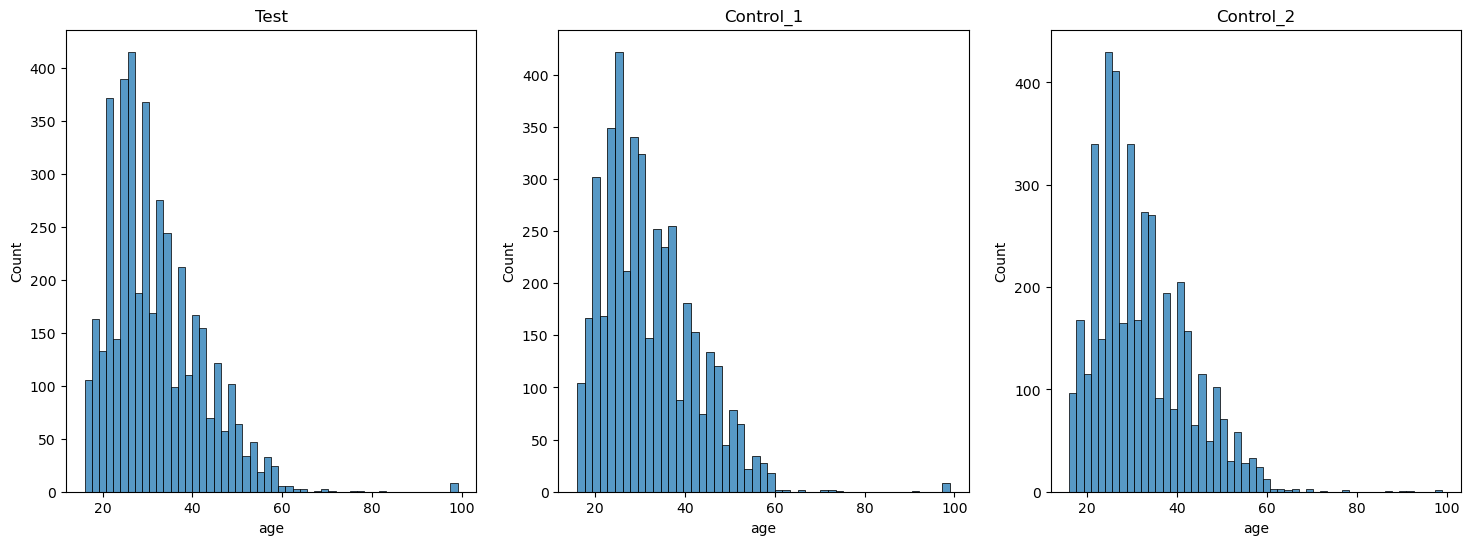

In [77]:
# здесь представлены распределения возраста для каждой группы 
ig, axes = plt.subplots(1, 3, figsize=(18, 6)) # 1 строка, 3 столбца

# график распределения возраста для выборки test
sns.histplot(data=users_all.query("group=='test'"), x='age', ax=axes[0])
axes[0].set_title('Test')
# график распределения возраста для выборки control_1
sns.histplot(data=users_all.query("group=='control_1'"), x='age', ax=axes[1])
axes[1].set_title('Сontrol_1')
# график распределения возраста для выборки control_2
sns.histplot(data=users_all.query("group=='control_2'"), x='age', ax=axes[2])
axes[2].set_title('Сontrol_2')

plt.show()

Видим, что распределения возраста в каждой выборке имеют ассиметрию (скошены вправо), выбросы в левой части, а также отличаются от нормального визуально. Проведём тесты Д'Агостино-Пирсона для каждого распределения возраста, чтобы проверить распределения на нормальность не только визуально. 

In [78]:
# тест Д'Агостино-Пирсона в pingouin
pg.normality(users_all.query("group=='test'").age, method='normaltest')

,W,pval,normal
age,977.341332,5.929614e-213,False


Распределение возраста в тестовой группе (test) не является нормальным.

In [79]:
# тест Д'Агостино-Пирсона в pingouin
pg.normality(users_all.query("group=='control_1'").age, method='normaltest')

,W,pval,normal
age,915.044035,1.998538e-199,False


Распределение возраста в первой контрольной группе (control_1) не является нормальным.

In [42]:
# тест Д'Агостино-Пирсона в pingouin
pg.normality(users_all.query("group=='control_2'").age, method='normaltest')

,W,pval,normal
age,628.103559,4.064857e-137,False


Распределение возраста во второй контрольной группе (control_2) не является нормальным.

Выберем статистический тест для сравнения распределений возраста в наших выборках. Мы выяснили что:

- тест будет проводиться по количественной/порядковой переменной (возрвст - измеримая величина)
- нам нужно сравнить распределения возраста по группам (одинаковые/разные)
- распределения возраста не прошли тест на нормальность
- распределения возраста имеют выбросы
- нам нужно сравнить распределения между 3 группами
- наблюдения в каждой группе независимы друг от друга

Получается, t-тест и дисперсионный анализ (ANOVA) нам точно не подойдут, так как нужно сравнивать распределения 3 выборок, причём все эти распределения отличаются от нормального. Так как у нас 3 группы для анализа, рассмотрение альтернативных вариантов t-теста (например, критерий Манна-Уитни) нам не подойдёт, так как все они специализируются именно на сравнении 2 групп. Поэтому рассмотрим непараметрическую альтернативу ANOVA, а именно - критерий Краскела-Уоллиса. Этот критерй как раз отлично подходит для сравнения нескольких независимых выборок количественных/порядковых переменных, если их распределения отличаются от нормального. У нас как раз такая ситуация.

Вывод: будем применять критерий Краскела-Уоллиса для сравнения распределений возраста между группами

Проводим тест, применяя критерий Краскела-Уоллиса 

Зафиксируем гипотезы для теста:

- H0: распределение возраста одинаковое во всех группах
- H1: распределение возраста отличается

In [83]:
# реализация теста, применяя критерий Краскела-Уоллиса
statistic, pvalue = kruskal(users_all.query("group=='test'").age,
                            users_all.query("group=='control_1'").age,
                            users_all.query("group=='control_2'").age)

print('statistic:', statistic)
print('p_value:', pvalue)

statistic: 1.1101328014539542
p_value: 0.5740341436464856


In [54]:
# интерпретируем результат
prob = 0.95
alpha = 1.0 - prob
if p_value <= alpha:
    print('Отклоняем H0')
else:
    print('Принимаем H0')

Принимаем H0


Итог теста по критерию Краскела-Уоллиса и интерпретация его результатов показали, что статистически значимой разницы в распределении возрастов между группами нет.

### Коэффицент привлекательности

Посмотрим на распределение коэффицента привлекательности внутри каждой выборки.

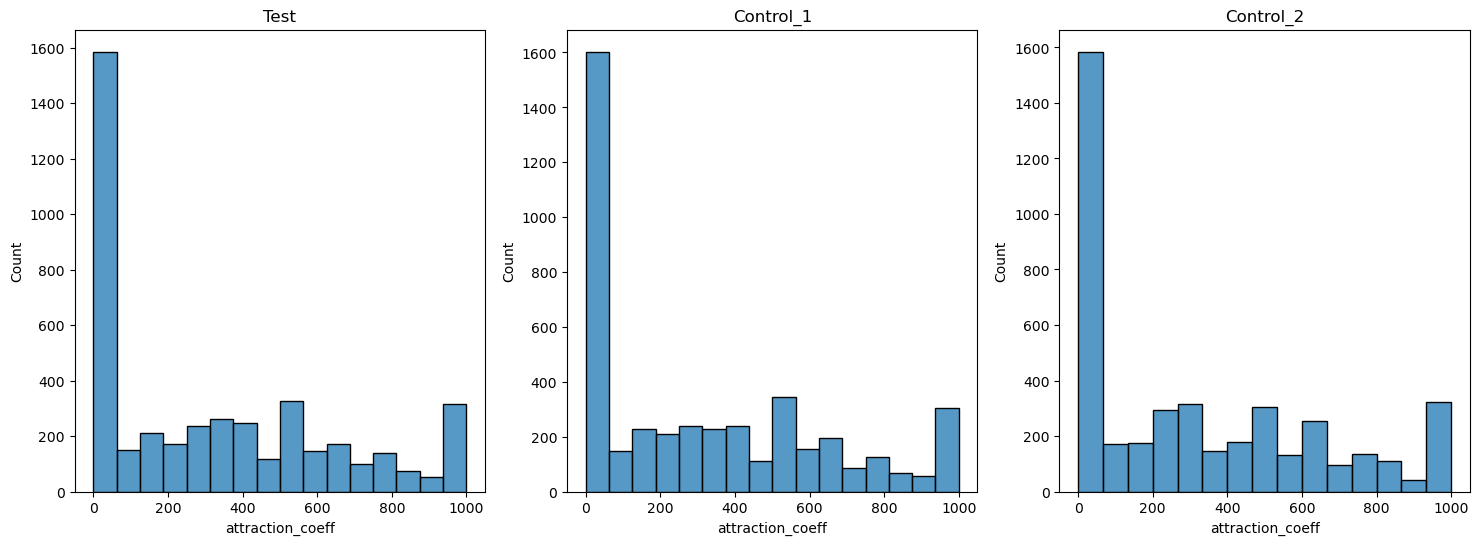

In [80]:
# здесь представлены распределения коэффицента привлекательности для каждой группы 
ig, axes = plt.subplots(1, 3, figsize=(18, 6)) # 1 строка, 3 столбца

# график распределения коэффицента привлекательности для выборки test
sns.histplot(data=users_all.query("group=='test'"), x='attraction_coeff', ax=axes[0])
axes[0].set_title('Test')
# график распределения коэффицента привлекательности для выборки control_1
sns.histplot(data=users_all.query("group=='control_1'"), x='attraction_coeff', ax=axes[1])
axes[1].set_title('Сontrol_1')
# график распределения коэффицента привлекательности для выборки control_2
sns.histplot(data=users_all.query("group=='control_2'"), x='attraction_coeff', ax=axes[2])
axes[2].set_title('Сontrol_2')
plt.show()

Видим, что распределения возраста в каждой выборке имеют ассиметрию (скошены вправо). Все распределения явно отличаются от нормального визуально. Здесь нам также нужно проанализировать распределения количественной переменной в трёх группах. Поступим аналогично, как с проверкой по распределениям возраста. Воспользуемся тестом по критерию Краскела-Уоллиса для сравнения распределений коэффицента привлекательности между группами.

Проводим тест, применяя критерий Краскела-Уоллиса

Зафиксируем гипотезы для теста:

- H0: распределение коэффицента привлекательности одинаковое во всех группах
- H1: распределение коэффицента привлекательности отличается


In [84]:
# реализация теста, применяя критерий Краскела-Уоллиса
statistic, pvalue = kruskal(users_all.query("group=='test'").attraction_coeff, 
                            users_all.query("group=='control_1'").attraction_coeff, 
                            users_all.query("group=='control_2'").attraction_coeff)

print('statistic:', statistic)
print('p_value:', pvalue)

statistic: 0.2626192225005614
p_value: 0.8769462199394717


In [85]:
# интерпретируем результат
prob = 0.95
alpha = 1.0 - prob
if p_value <= alpha:
    print('Отклоняем H0')
else:
    print('Принимаем H0')

Принимаем H0


Итог теста по критерию Краскела-Уоллиса и интерпретация его результатов показали, что статистически значимой разницы в распределении коэффицента привлекательности между группами нет.

### Страны

По условиям задачи, изменения цены произошли не во всех странах, а лишь по нескольким. Это важно учесть, потому что, если при анализе результатов эксперимента мы будем использовать данные клиентов из стран, которые не участвовали в эксперименте, это может исказить результаты и привести к ложному выводу. Нам нужно оставить только те данные клиентов, которые принадлежат странам, где проводился эксперимент. Получается, нам нужно оставить только те страны, которые имеют пересечение как с тестовой, так и с обеими контрольными группами. 

In [87]:
# получим множество с уникальными названиями стран, где проводился эксперимент
test_countries = set(users_all.query("group=='test'").country)
c1_countries = set(users_all.query("group=='control_1'").country)
c2_countries = set(users_all.query("group=='control_2'").country)

common_countries = test_countries & c1_countries & c2_countries

In [65]:
# common_countries

In [93]:
# проверим размерность исходного датасета
users_all.shape

(12912, 14)

In [91]:
# отфильтруем данные в датасете пользователей, чтобы остались только те, кто имеет отношение к странам, где тестировали новую цену
users_all_common = users_all[users_all.country.isin(common_countries)]
# users_all_common

In [92]:
# проверим размерность финального датасета с информацией о пользователях
users_all_common.shape

(12832, 14)

### Результат проверки данных о пользователях по демографическим признакам

В результате проверок по демографическим признакам, мы убедились что группы сопоставимы между собой по составу пользователей. Теперь мы можем утверждать, что распределения стран, возраста, пола и коэффицента привлекательности пользователей идентичны во всех выборках. Конечно, у наших пользователей есть и другие демографические признаки, но их проверку можно опустить, так как все основные демографические признаки, которые могут оказать существенное влияние на результаты эксперимента, мы проверили. 

Получается, отсутствие статистически значимых различий по демографическим характеристикам позволяет считатьэксперимент валидным и интерпретировать различия в метриках как эффект изменения именно стоимости премиум-подписки.

На этом можно завершить проверку датафрейма с информацией о юзерах. Всю основную информацию, которая понадобится нам для дальнейшего анализа, мы проверили на корректность. 

___
## Предобработка данных о транзакциях

Теперь подробнее рассмотрим датафрейм с информацией о транзакциях:

In [95]:
# добавим признак группы в каждый датафрейм с информацией о транзакциях
transactions_test_df['group'] = 'test'
transactions_control_1_df['group'] = 'control_1'
transactions_control_2_df['group'] = 'control_2'

# объединяем всю информацию о транзакциях в один датафрейм
transactions_all = pd.concat([transactions_test_df, transactions_control_1_df, transactions_control_2_df])
# transactions_all.head(3)

In [96]:
# размеры датафрейма
transactions_all.shape

(1608, 9)

In [97]:
# типы данных в колонках датафрейма
transactions_all.dtypes

uid             float64
country          object
joined_at        object
paid_at          object
revenue         float64
payment_id      float64
from_page        object
product_type     object
group            object
dtype: object

In [98]:
# Проверка на Null значения
transactions_all.isna().sum()

uid             630
country         630
joined_at         0
paid_at           0
revenue         630
payment_id      630
from_page       630
product_type    630
group             0
dtype: int64

In [99]:
print(f"Процент пропущенных значений в датафрейме transactions_all составляет {round(transactions_all.uid.isna().mean() * 100, 2)}%")

Процент пропущенных значений в датафрейме transactions_all составляет 39.18%


Здесь есть опасный момент для нашего анализа. Мы выяснили, что есть пропущенные значения в колонке uid. Это говорит об ошибке при сборе данных. Для того чтобы продолжить работу с данными, нам нужно исключить все строки с Null значениями в колонке uid. 

Избавимся от подобных строк:

In [100]:
# удаляем все строки из датафрейма, где uid принимает знначение Null
transactions_all = transactions_all.dropna(subset=['uid'])

In [101]:
# проверим актуальный размер датафрейма транзакций
transactions_all.shape

(978, 9)

Заметим, что все колонки в датафрейме транзакций, которые имеют тип данных float, можно заменить на int. Так мы гарантировано не потеряем данные при объединении датафреймов с юзерами и транзакциями. В датафрейме с транзакциями у нас uid и total_revenue являются колонками типа int. То что в датафрейме транзакций подобные колонки оказались типа float, скорее всего, является свидетельством того, что колонки revenue и uid имели Null значения. Тип int не поддерживает Null значения.
Также можем привести колонку payment_id к типу int. Так как эти данные хранят id платёжной системы

Убедимся, что все перечисленные выше колонки не имеют дробных значений на самом деле. Чтобы мы случайно не испортили данные преобразованием типов

In [102]:
# проверка что значения uid совпадают как в типе int, так и в типе float
(transactions_all['uid'] == transactions_all['uid'].astype(int)).all()

np.True_

In [103]:
# проверка что значения payment_id совпадают как в типе int, так и в типе float
(transactions_all['payment_id'] == transactions_all['payment_id'].astype(int)).all()

np.True_

In [104]:
# проверка что значения revenue совпадают как в типе int, так и в типе float
(transactions_all['revenue'] == transactions_all['revenue'].astype(int)).all()

np.True_

Выше мы подтвердили, что все колонки имеют идентичные значения что в типе int, что в типе float. Значит, это отличный повод оптимизировать все эти три колонки и перевести их в int. Это поможет нам далее для корректного объединения данных и сэкономит ресурсы при проведении рассчётов.

In [105]:
# приводим к типу int весь float в датафрейме
transactions_all = transactions_all.astype({
    'uid': 'int64',
    'payment_id': 'int64',
    'revenue': 'int64'
})

Также приведём все колонки с датами к типу datetime

In [106]:
# приводим колонки с датами к типу datetime
transactions_all['joined_at'] = pd.to_datetime(transactions_all['joined_at'])
transactions_all['paid_at'] = pd.to_datetime(transactions_all['paid_at'])

In [107]:
# проверим все актуальные типы данных в датафрейме, которые получились после всех преобразований
transactions_all.dtypes

uid                      int64
country                 object
joined_at       datetime64[ns]
paid_at         datetime64[ns]
revenue                  int64
payment_id               int64
from_page               object
product_type            object
group                   object
dtype: object

С типами данных мы разобрались. Далее сделаем ещё несколько проверок, которые помогут отсеять данные с некорректной логикой, если такие есть в нашем датафрейме.


In [108]:
# проверка данных на количество полных дубликатов строк
transactions_all.duplicated().sum()

np.int64(33)

Найдены полные дубликаты строк в датафрейме оплат. Это значит, что некоторые оплаты полностью задублировались. Необходимо очистить наш датафрейм от таких данных. Видимо, произошла ошибка у нашей системы сплитования. Однако, какой бы не была причина ошибки, мы не можем использовать задвоенные данные в дальнейшем анализе. Дубликаты оплат могут исказить реальный эффект влияния изменения цены, который мы хотели измерить при проведении теста.

In [109]:
# удаляем все дубликаты строк из датафрейма
transactions_all = transactions_all.drop_duplicates()

Также нарушением логики в данных могут быть такие строки, где регистрация пользователя произошла позже чем совершение покупки. Мы хотели замерять эффект от изменений именно на новых пользователях, но если дата покупки была раньше даты присоединения к продукту, по факту такой пользователь не может считаться новым. Это похоже опять же на ошибку в данных. Учитывать такие оплаты (до регистрации) будет некорректно в рамках нашего анализа.

In [110]:
# проверим количество оплат, где дата оплаты услуги была раньше даты регистрации пользователя
transactions_all[transactions_all['paid_at'] < transactions_all['joined_at']].uid.count()

np.int64(162)

Как раз в наших данных оказалось 162 оплаты, где покупка была раньше регистрации. Таких пользователей считать за новых мы не можем. Удаляем все подобные транзакции из данных

In [111]:
# убираем из данных все транзакции, где оплата была раньше регистрации
transactions_all = transactions_all[~(transactions_all['paid_at'] < transactions_all['joined_at'])]

Теперь рассмотрим какие типы транзакций есть в наших данных и займёмся отбором того среза данных, который необходим нам для проведения анализа эффекта наших изменений. Для обозначения типа транзакций у нас есть две колонки (payment_id и product_type). Посмотрим на них поробнее и выберем ту колонку, по которой будем отсеивать данные

In [112]:
# смотрим какие значения принимает колонка payment_id
transactions_all.payment_id.value_counts()

payment_id
147    345
19     220
67      86
146     80
68      42
0        7
127      3
Name: count, dtype: int64

In [113]:
# смотрим какие значения принимает колонка product_type
transactions_all.product_type.value_counts()

product_type
coins               295
premium_no_trial    256
trial_premium       131
other_type          101
Name: count, dtype: int64

Заметим подозрительный момент: что типов продуктов (product_type) меньше чем id продуктов (payment_id). 

**Из условий задачи product_type (тип продукта):**

- trial_premium – пробная премиум-подписка
- premium_no_trial – премиум-подписка без пробной
- coins – подписка за внутреннюю валюту
- other_type – другое

Положим:
- product_type - тип продукта
- payment_id - тип платёжной системы


В рамках нашего эксперимента была изменена стоимость только премиум-подписки, следовательно, мы должны рассматривать дальше только данные, связанные с премиум подпиской (смотреть и прибыль и конверсию только по премиум подписке). Данные, связанные с другими категориями, могут сильно отразиться на результатах анализа и исказить отслеживаемый эффект.

In [114]:
# можем посмотреть какую большую долю выручки, в имеющихся данных о транзакциях, у нас занимают другие типы покупок
transactions_all.groupby(by=['group','product_type']).agg({'revenue':'sum'}).sort_values(by='revenue', ascending=False)

revenue
group     product_type             
test      premium_no_trial   726830
control_1 premium_no_trial   717353
          coins              710294
control_2 premium_no_trial   682487
test      trial_premium      605228
control_1 trial_premium      599066
test      coins              485602
control_2 trial_premium      404989
          coins              290706
control_1 other_type         147264
test      other_type         112814
control_2 other_type         102713

Видим, что действительно очень большая часть выручки сосредоточена в тех категориях, которые не интересны нам для проведения анализа. От всех категорий, которые никак не связаны с премиум подпиской, необходимо избавиться.

In [115]:
# также посмотрим как распределяется количество транзакций по каждому типу продуктов внутри групп
pd.crosstab(transactions_all.product_type, transactions_all.group)

group,control_1,control_2,test
product_type,,,
coins,113,99,83
other_type,42,35,24
premium_no_trial,95,96,65
trial_premium,51,33,47


Тут видно, что действительно большую часть от выручки составляют оплаты по внутренней валюте, например. Особенно перекос заметен в категории test: там больше всего транзакций было связано именно с покупкой Coins. Если мы будем учитывать coins, наши выводы могут быть очень сильно искажены (нпример, это может создать ложный эффект для конверсии). 

Нам следует исключить категории, которые никак не относятся к премиум-подписке (coins, other_type), потому что эти категории могут исказить анализ результатов a/b теста.

In [116]:
# убираем из данных категории, которые не касаются премиум-подписок (coins, other_type)
premium_transactions = transactions_all[
    transactions_all['product_type'].isin(['premium_no_trial','trial_premium'])]

Перед тем как объединять данные о транзакциях и о юзерах, мы должны сгруппировать данные о транзакциях так, чтобы каждому юзеру соответствовала одна строка с информацией о транзакциях. Проверим есть ли у нас в датафрейме юзеры, которые совершили несколько оплат или же у нас одна транзакция уже соответствует одному юзеру

In [117]:
if premium_transactions.uid.nunique() == premium_transactions.uid.count():
    print('Одна транзакция - один клиент')
else:
    print('В данных есть клиенты, которые совершили несколько оплат')

В данных есть клиенты, которые совершили несколько оплат


Это могли быть, например, продления подписок. Посмотрим подробнее на тех юзеров, которые сделали несколько оплат подробнее.

In [118]:
# юзеры которые имеют больше одной оплаты
more_one_payment_users = (premium_transactions.groupby(by='uid', as_index=False)
                          .agg({'paid_at':'count'})
                          .query('paid_at > 1')
                          .sort_values(by='uid', ascending=False))
# more_one_payment_users
print(f"Количество пользователей, которые совершили больше одной оплаты премиума {int(more_one_payment_users.paid_at.count())}")

Количество пользователей, которые совершили больше одной оплаты премиума 13


In [119]:
# юзеры которые имеют больше одной уникольной оплаты. проверим задвоение оплат
more_one_unique_payment_users = (premium_transactions.groupby(by='uid', as_index=False)
                                 .agg({'paid_at':'nunique'})
                                 .query('paid_at > 1')
                                 .sort_values(by='uid', ascending=False))
# more_one_unique_payment_users
print(f"Количество пользователей, которые совершили больше одной уникальной оплаты {int(more_one_unique_payment_users.paid_at.count())}")

Количество пользователей, которые совершили больше одной уникальной оплаты 9


Видим, что у нас нашлись юзеры, которые имеют одинаковые по времени проведения оплаты. Такие оплаты вряд ли можно считать уникальными и валидными. По условии задачи, премиум (как пробный, так и основная подписка), даётся на месяц. Получается, повторная покупка премиума тоже должна происходить у клиента не раньше чем через месяц. Всё что отличается от этого паттерна - считаем ошибкой.

In [120]:
# посмотрим на юзеров, которые имеют дублирующиеся оплаты
set(more_one_payment_users.uid) - set(more_one_unique_payment_users.uid)

{891216033, 891219540, 891725043, 892101909}

Подробно посмотрим на юзеров, которые имеют неуникальные оплаты:

In [121]:
premium_transactions.query("uid == 892101909")

,uid,country,joined_at,paid_at,revenue,payment_id,from_page,product_type,group
210,892101909,France,2017-10-21 03:28:00,2017-10-21 03:39:00,6422,147,none,premium_no_trial,control_1
347,892101909,France,2017-10-21 03:28:00,2017-10-21 03:39:00,6422,0,none,premium_no_trial,control_1


Здесь видно, что оплаты полностью идентичны. Различие только в payment_id. Возможно, из-за технического сбоя, оплата задвоилась с указанием ложного payment_id.

In [122]:
premium_transactions.query("uid == 891725043")

,uid,country,joined_at,paid_at,revenue,payment_id,from_page,product_type,group
152,891725043,United Arab Emirates,2017-10-29 00:49:00,2017-10-29 07:48:00,9217,147,none,premium_no_trial,test
220,891725043,United Arab Emirates,2017-10-29 00:49:00,2017-10-29 07:48:00,9217,0,none,premium_no_trial,test


Аналогичная проблема. Снова задвоение оплаты с другим payment_id

In [123]:
premium_transactions.query("uid == 891219540")

,uid,country,joined_at,paid_at,revenue,payment_id,from_page,product_type,group
90,891219540,Australia,2017-07-11 10:50:00,2017-07-11 10:58:00,4719,0,none,premium_no_trial,control_2
144,891219540,Australia,2017-07-11 10:50:00,2017-07-11 10:58:00,4719,147,none,premium_no_trial,control_2


Аналогичная проблема. Снова задвоение оплаты с другим payment_id

In [124]:
premium_transactions.query("uid == 891216033")

,uid,country,joined_at,paid_at,revenue,payment_id,from_page,product_type,group
138,891216033,United States of America,2017-07-11 12:33:00,2017-07-11 12:47:00,6292,0,autoreply_message,premium_no_trial,control_1
269,891216033,United States of America,2017-07-11 12:33:00,2017-07-11 12:47:00,6292,147,autoreply_message,premium_no_trial,control_1


Аналогичная проблема.

In [125]:
# проверим количество оплат, которые имеют payment_id = 0
premium_transactions.query('payment_id == 0').uid.count()

np.int64(4)

In [126]:
# тут можно подробно увидеть все эти оплаты с (payment_id = 0) в одном месте
# premium_transactions.query('payment_id == 0')

Отсюда можно сделать вывод, что оплаты, которые имеют payment_id = 0, являются ошибками и задублировались. Исключим эти оплаты из наших данных.

In [127]:
# убираем из данных оплаты где payment_id = 0
premium_transactions = premium_transactions[~(premium_transactions['payment_id'] == 0)]

Также подробнее посмотрим насколько логика оплаты в наших данных соотноситься с условиями эксперимента. Посмотрим как покупки распределены по датам в наших данных

In [128]:
# посмотрим на описательные статистики колонки с датами покупок
premium_transactions.paid_at.describe()

count                              383
mean     2017-09-27 23:06:42.610966016
min                2017-01-11 05:16:00
25%                2017-10-13 00:52:30
50%                2017-10-23 13:42:00
75%                2017-10-30 00:30:30
max                2017-12-11 23:28:00
Name: paid_at, dtype: object

Видим, что у нас довольно сильный разброс дат. Эксперимент проходил в течение всего года. Мы помним, что по условиям задачи:
- мы хотим проверить какой эффект оказало изменение цены премиум подписки на **новых пользователей**. То есть на людей, которые только купили подписку.
- премиум подписка имеет логику **ежемесячкого списания**. То есть купить две или более подписок в месяц на одном аккаунте должно быть нельзя. Это противоречит логике подписки (как основной, так и пробной)

Поэтому назначим дополнительную метку в наших данных: введём колонку, которая отражает информацию о месяце оплаты. Это будет работать корректно, так как оплаты у нас проводились в пределах одного года. Значит, один порядковый номер будет соответствовать только одному месяцу (например, если бы эксперимент шёл два года, то порядковый номер соответствовал бы сразу двум месяцам)

In [129]:
# сделаем новую колонку в данных с информацией о порядковом месяце оплаты
premium_transactions_df = premium_transactions.copy()
premium_transactions_df['paid_month'] = premium_transactions_df.paid_at.dt.month
# premium_transactions_df

Выше мы упомянули условия задачи. Получается, если один и тот же тип продукта был два и более раз куплен одним пользователем в течение одного месяца - это считается ошибкой в логике наших данных и такого быть не должно. Мы имеем право убрать такие транзакции из данных

In [130]:
# убираем оплаты одного и того же продукта в течение одного месяца, так как это противоречит логике подписки
premium_transactions_df = (
    premium_transactions_df
    .sort_values('paid_at')
    .drop_duplicates(['uid','country','joined_at','product_type','group','paid_month'])
)

Также напомним, что по условиям задачи, мы хотели оценить эффект изменения цены именно на новых пользователях. Так как премиум-подписка это ежемесячная история, то есть рассчитанная примерно на 30 дней, положим, что новые пользователи - это клиенты, у которых с момента регистрации до первой покупки прошло не более 30 дней. Пусть все пользователи, которые совершили первую покупку позже первых 30 дней с момента регистрации будут считаться "старыми". Таких пользователей уже нельзя считать "новыми".

Например, если пользователь платит через месяц и более, на его решение могли повлиять другие факторы, которые никак не связаны с нашим экспериментом по изменению стоимости. Это могут быть очень разные фкторы: 
- другие версии приложения
- маркетинговые акции
- сезонность
- итд

Получается, если мы будем брать в рассчёт таких пользователей, это может исказить результаты эксперимента и создать ложный эффект.

In [131]:
# проверим есть ли в наших данных проблема с большим промежутком времени от регистрации до первой оплаты
# для этого посмотрим описательные статистики по такой величине как "количество дней до оплаты"
premium_transactions_df.assign(
    days_to_payment=(premium_transactions_df['paid_at'] - premium_transactions_df['joined_at']).dt.days
).sort_values('days_to_payment', ascending=False).query('days_to_payment > 30').days_to_payment.describe()

count     86.000000
mean     159.906977
std       69.330687
min       31.000000
25%       96.000000
50%      155.500000
75%      214.000000
max      306.000000
Name: days_to_payment, dtype: float64

Видим, что для наших данных это действительно актуальная проблема. Медианное значение по количеству дней от регистрации до оплаты составляет более 150 дней (а это более 5 месяцев!). Это очень большой промежуток с момента регистрации до покупки премиума. Таких юзеров ошибочно учитывать при проведении анализа по новым пользователям. 

Посмотрим сколько таких юзеров в наших данных:

In [132]:
# количество юзеров, которые сделали свои оплаты позже первых 30 дней с момента регистрации
old_paid_users = premium_transactions_df.assign(
    days_to_payment=(premium_transactions_df['paid_at'] - premium_transactions_df['joined_at']).dt.days
).sort_values('days_to_payment', ascending=False).query('days_to_payment > 30').uid.nunique()

# кольчество уникальных юзеров, по которым у нас есть данные о транзакциях
all_paid_users = premium_transactions_df.uid.nunique()

# процент юзеров, которые совершили оплату позже первых 30 дней с момента регистрации
old_users_score = round((old_paid_users * 100) / all_paid_users, 2)
print(f"Процент юзеров, которые совершили оплату позже первых 30 дней с момента регистрации составляет {old_users_score}%")

Процент юзеров, которые совершили оплату позже первых 30 дней с момента регистрации составляет 22.91%


In [133]:
# юзеры, которые сделали более одной оплаты в принципе
premium_transactions_df.groupby(by='uid', as_index=False).agg({'paid_at':'count'}).query('paid_at > 1').sort_values(by='uid', ascending=False)

,uid,paid_at
368,892435536,2
349,892366260,2
338,892339626,2
42,891264903,2


Мы видим, что почти 23% транзакций, были совершены пользователями сильно позже регистрации. А именно, среди таких транзакций больше половины были совершены спустя почти полгода с момента регистрации. 

Также учтём, что юзеров с такой проблемой (слишком поздние платежи) у нас целых 85 штук, а юзеров с повторными платежами в рамках продления подписки (которые также получается совершены позже 30 дней с момента регистрации) всего 4. Поэтому мы можем принебречь данными о продлении подписок. Данные о повторных платежах будут также исключены из датасета далее. 

Будем отслеживать эффект изменения цены именно по конверсии в первую оплату премиум-подписки и по прибыли с первой оплаты премиум-подписки от новых пользователей.

In [134]:
# определим порядок платежей. зададим порядковые номера платежам в новой колонке 
premium_transactions_df = premium_transactions_df.sort_values(['uid','paid_at'])

premium_transactions_df['payment_number'] = premium_transactions_df.groupby('uid').cumcount() + 1

получим что:
- payment_number = 1 это первая оплата
- payment_number = 2 это вторая оплата

In [135]:
# можем посмотреть что у нас получилось и как теперь выглядят данные
# premium_transactions_df.head(3)

In [136]:
# избавляемся от всех оплат, которые были совершены позже 30 дней с момента регистрации юзеров
premium_clean = premium_transactions_df[
    ((premium_transactions_df['paid_at'] - premium_transactions_df['joined_at']).dt.days <= 30)]

Теперь проверим количество повторных оплат и исключим их, чтобы не создавать искусственно зашумление прибыли. Будем анализировать только прибыль от первой оплаты, а также конверсию в первую оплату, поэтому малочисленные данные о продлении подписки нам не нужны.

In [137]:
# юзеры с повторными оплатами
premium_clean.groupby(by='uid', as_index=False).agg({'paid_at':'count'}).query('paid_at > 1').sort_values(by='uid', ascending=False)

,uid,paid_at
265,892366260,2
254,892339626,2


Посмотрим на них подробнее, чтобы точно убедиться, что мы не потеряем критически важных данных

In [138]:
premium_clean.query('uid == 892366260')

,uid,country,joined_at,paid_at,revenue,payment_id,from_page,product_type,group,paid_month,payment_number
84,892366260,United Kingdom (Great Britain),2017-10-15 15:04:00,2017-10-15 15:49:00,6292,147,left_sidebar_menu,premium_no_trial,control_1,10,1
103,892366260,United Kingdom (Great Britain),2017-10-15 15:04:00,2017-11-14 16:50:00,6292,147,left_sidebar_menu,premium_no_trial,control_1,11,2


In [139]:
premium_clean.query('uid == 892339626')

,uid,country,joined_at,paid_at,revenue,payment_id,from_page,product_type,group,paid_month,payment_number
122,892339626,United States of America,2017-10-15 23:21:00,2017-10-17 18:58:00,2613,68,none,premium_no_trial,test,10,1
104,892339626,United States of America,2017-10-15 23:21:00,2017-11-11 01:05:00,2587,68,none,premium_no_trial,test,11,2


In [140]:
# тут можно подробно увидеть все эти оплаты с (payment_number == 2) в одном месте
# premium_clean.query('payment_number == 2')

Это действительно просто продление подписок. Так как мы договорились ранее, что быдем работать с метриками конверсии и выручки только по первой оплате, исключим эти данные (только о продлении подписки, то есть о второй оплате пользователей) из датасета.

In [141]:
# убираем повторные оплаты из данных
premium_clean = premium_clean[(premium_clean['payment_number'] == 1)]

In [142]:
# проверим размер получившегося датасета с информацией о транзакциях
premium_clean.shape

(287, 11)

In [143]:
# проверим всем ли юзерам из таблицы транзакций теперь соответствует только одна строка (это нужно для корректного объединения данных и дальнейшего анализа)
if premium_clean.uid.count() == premium_clean.uid.nunique():
    print("Все юзеры в таблице уникальны")
else:
    print("Внимание! Есть дубликаты uid в таблице транзакций")

Все юзеры в таблице уникальны


На этом месте зафиксируем, что в наших данных по транзакциям остались только первые оплаты новых юзеров по премиум подпискам (как пробным, так и обычным) в единственном экземпляре. То есть каждому юзеру в таблице транзакций соответствует одна строка. Все uid уникальны.

Также ранее мы обращали внимание, что в таблице транзакций количество разновидностей payment_id было больше чем количество разновидностей product_type. Проверим как сейчас с этим обстоят дела, когда мы привели данные к "чистому" виду. Настало время разобраться окончательно

In [144]:
# смотрим какие значения принимает колонка payment_id
premium_clean.payment_id.value_counts()

payment_id
147    255
68      32
Name: count, dtype: int64

По условиям задачи, мы меняли стоимость подписки через две новые платёжные системы. Как раз у нас осталось только два вида payment_id (id платёжной системы). 

In [145]:
# смотрим какие значения принимает колонка product_type
premium_clean.product_type.value_counts()

product_type
premium_no_trial    213
trial_premium        74
Name: count, dtype: int64

In [146]:
# сгруппируем данные в разрезе payment_id=147 по типу продукта и посмотрим количество транзакций в каждом
premium_clean.query('payment_id == 147').groupby(by='product_type').agg({'paid_at':'count'})

,paid_at
product_type,
premium_no_trial,181
trial_premium,74


In [147]:
# сгруппируем данные в разрезе payment_id=68 по типу продукта и посмотрим количество транзакций в каждом
premium_clean.query('payment_id == 68').groupby(by='product_type').agg({'paid_at':'count'})

,paid_at
product_type,
premium_no_trial,32


Проверим отличается ли распределение покупок внутри групп в разрезе платёжных систем. То есть проверим оказали ли платёжные системы влияние на покупки премиума. Так как мы хотим сравнить распределения категориальной переменной (выбранный тип платёжной системы/тип выборки), воспользуемся тестом хи-квадрат. 

Проводим тест хи-квадрат

Зафиксируем гипотезы для теста хи-квадрат:

- H0: распределение продаж через две платёжные системы одинаковое во всех группах
- H1: распределение продаж через две платёжные системы отличается

In [155]:
cross_pay_id = pd.crosstab(premium_clean.payment_id, premium_clean.group)
cross_pay_id

group,control_1,control_2,test
payment_id,,,
68,13,11,8
147,92,93,70


In [150]:
# реализация теста хи-квадрат
chi2, p_value, dof, expected = chi2_contingency(cross_pay_id)

print('chi2:', chi2)
print('p_value:', p_value)

chi2: 0.2579473824786327
p_value: 0.8789970905654838


In [151]:
# интерпретируем результат
prob = 0.95
alpha = 1.0 - prob
if p_value <= alpha:
    print('Отклоняем H0')
else:
    print('Принимаем H0')

Принимаем H0


Итог теста хи-квадрат и интерпретация его результатов показали, что статистически значимой разницы в распределении продаж через две платёжные системы между группами нет.

___
## Анализ соотношения покупок внутри категории премиум-подписок

В ходе эксперимента мы меняли стоимость основной премиум-подписки, а стоимость пробной премиум-подписки оставалась неизменной. Интересно посмотреть, оказало ли наше изменение влияние на соотношение покупок пробного и основного премиума внутри групп. Другими словами, заставили ли наши изменения чаще или реже выбирать премиум-подписку к покупке.

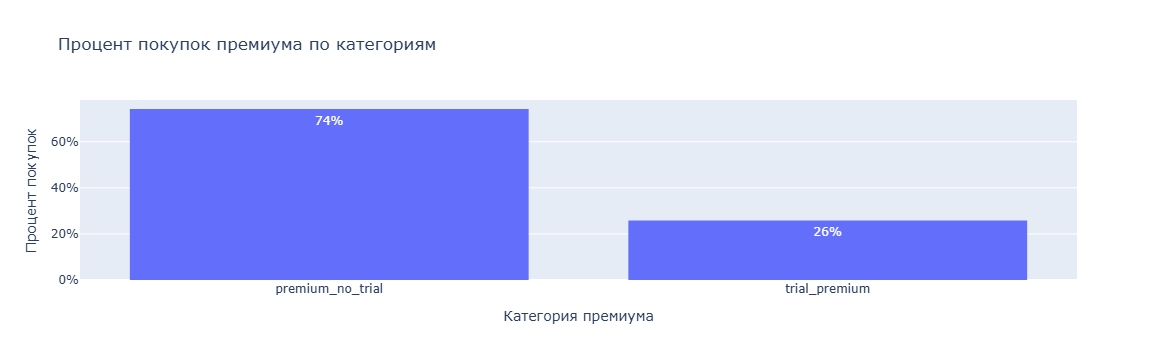

In [156]:
# построим график процентного соотношения покупок разных видов премиума
fig = px.histogram(premium_clean, x='product_type',
                   histnorm='probability density',
                   text_auto=True,
                   title='Процент покупок премиума по категориям')

fig.update_layout(
    yaxis_title='Процент покупок',
    xaxis_title='Категория премиума',
    yaxis_tickformat='.0%'
)
fig.show()

Мы видим, что пользователи намного чаще (почти в 3 раза чаще) выбирают покупку именно премиум-подписки без пробного периода. Изменением цены именно этой подписки и занимался наш эксперимент. 

Исследуем, связана ли высокая доля покупок премиума с нашим экспериментом, или этот эффект не относится к нашему эксперименту. Таким образом, нам нужно проверить есть ли зависимость между категориальными переменными: тип продукта и тип группы пользователей при проведении эксперимента.

Зависит ли тип покупки от группы? Повлияло ли изменение цены премиума на стремление пользователей выбирать определнный тип премиума? Найдём ответ на эти вопросы в данных. Сравним расределение категорий

In [157]:
# таблица сопряжённости по количеству покупок (тип продукта/группа юзеров)
counts_cross_premium = pd.crosstab(premium_clean.product_type, premium_clean.group)
counts_cross_premium

group,control_1,control_2,test
product_type,,,
premium_no_trial,79,83,51
trial_premium,26,21,27


На первый взгляд мы видим, что количество покупок премиума без пробного периода действительно численно возрасло в контрольных группах. Проверим так ли это на самом деле с помощью статистического теста. Но перед этим посмотрим на пропорции покупок разных видов премиума внутри каждой группы.

In [158]:
# таблица пропорций покупок разных типов премиума внутри групп
proportion_premium = (
    premium_clean.groupby(by='group', as_index=False)['product_type']
    .value_counts(normalize=True)
    .sort_values(by='group', ascending=False))

# proportion_premium

In [159]:
# запивотим таблицу пропорций для более наглядного представления
proportion_premium_pivot = proportion_premium.pivot(
    index='group',
    columns='product_type',
    values='proportion'
)

proportion_premium_pivot

product_type,premium_no_trial,trial_premium
group,,
control_1,0.752381,0.247619
control_2,0.798077,0.201923
test,0.653846,0.346154


Визуализируем табличное представление для более наглядной репрезентации пропорций

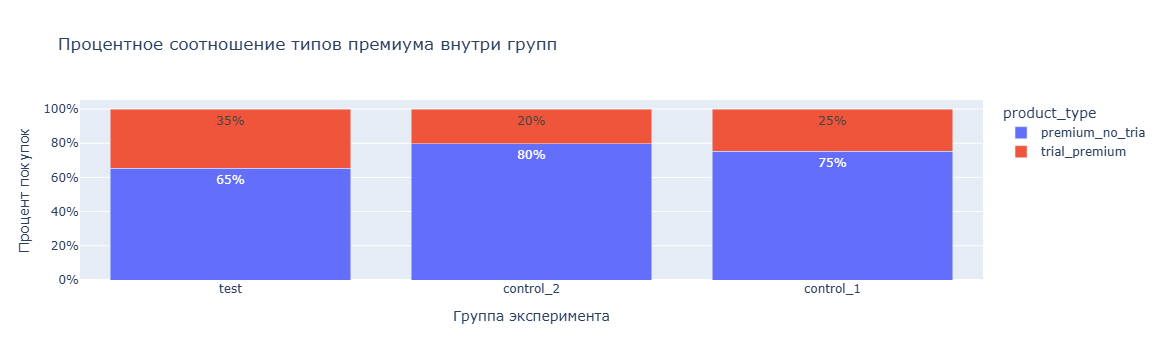

In [160]:
# процентное соотношение типов премиума внутри групп
fig = px.bar(
    proportion_premium,
    x='group',
    y='proportion',
    color='product_type',
    barmode='stack',
    text_auto=True,
    title='Процентное соотношение типов премиума внутри групп'
)

fig.update_layout(
    yaxis_title='Процент покупок',
    xaxis_title='Группа эксперимента',
    yaxis_tickformat='.0%'
)

fig.show()

Отсюда видно, что в тестовой выборке (test) наибольший процент пробных подписок, а в обеих контрольных выборках (control_1, control_2) больший процент покупок сразу премиум-подписок. Делать вывод только по графику – не очень хорошо, поэтому проверим нашу гипотезу с помощью статистического теста.

Получается, нам хочется понять есть ли зависимость между двумя категориальными переменными (группа эксперимента/тип премиум подписки). Применим тут хи-квадрат тест для сравнения распределений категориальных переменных. 
Это необходимо, чтобы понять повлияли ли изменения (касательно цены премиум подписок) на пробные подписки.

### Проводим тест хи-квадрат

Зафиксируем гипотезы для теста хи-квадрат:
- H0: распределение типов покупок одинаковое во всех группах
- H1: распределение типов покупок отличается

In [161]:
# реализация теста хи-квадрат
chi2, p_value, dof, expected = chi2_contingency(counts_cross_premium)

print('chi2:', chi2)
print('p_value:', p_value)

chi2: 4.935734881685587
p_value: 0.08476543369185927


In [162]:
# интерпретируем результат
prob = 0.95
alpha = 1.0 - prob
if p_value <= alpha:
    print('Отклоняем H0')
else:
    print('Принимаем H0')

Принимаем H0


Итог теста хи-квадрат и интерпретация его результатов показали, что статистически значимой разницы в распределении типов покупок премиума между группами нет.

Получается, изменение цены никак не повлияло на стремление пользователей отдавать предпочтение какому-то конкретному типу премиума. Но в данном эксперименте нам наиболее интересно посмотреть есть ли эффект на конкретном виде подписки - обычная премиум-подписка. Далее сосредоточемся именно на ней

___

## Анализ конверсии (CR) в первую покупку премиум-подписки

Все данные по транзакциям мы уже подготовили. Для начала объединим данные о транзакциях и о пользователях, чтобы начать анализ основных метрик A/B эксперимента (конверсия, ARPU, ARPPU).

In [168]:
# необходимые данные из датафрейма транзакций
premium_data = premium_clean[['uid','revenue','product_type','group']]
# premium_data

In [169]:
# необходимые данные из датафрейма пользователей
users_data = users_all_common[['uid','age','attraction_coeff','country','gender','was_premium','is_premium','group']]
# users_data

In [170]:
# объединяем данные транзакций и юзеров
general_df = users_data.merge(premium_data, on=['uid','group'], how='left')

# избавимся от NaN значений в данных перед анализом
general_df['revenue'] = general_df['revenue'].fillna(0)
general_df['product_type'] = general_df['product_type'].fillna('no_purchases')

In [171]:
# посмотрим на объединённый датафрейм, который у нас получился
general_df.head(3)

,uid,age,attraction_coeff,country,gender,was_premium,is_premium,group,revenue,product_type
0,892309896,27,685,United States of America,1,False,False,test,0.0,no_purchases
1,892044516,27,0,Germany,1,False,False,test,0.0,no_purchases
2,892185708,45,44,Israel,1,False,False,test,0.0,no_purchases


Сделаем небольшой обзор полученного датафрейма, чтобы убедиться, что никаких критичных проблем не произошло после объединения данных

In [172]:
# проверим размеры датафрейма
general_df.shape

(12832, 10)

In [173]:
# посмотрим на типы данных колонок датафрейма
general_df.dtypes

uid                   int64
age                   int64
attraction_coeff      int64
country              object
gender                int64
was_premium            bool
is_premium             bool
group                object
revenue             float64
product_type         object
dtype: object

In [174]:
# убедимся, что в объединённом датафрейма отсутствуют пропущенные значения
general_df.isna().sum()

uid                 0
age                 0
attraction_coeff    0
country             0
gender              0
was_premium         0
is_premium          0
group               0
revenue             0
product_type        0
dtype: int64

In [175]:
# посмотрим как распределены юзеры между выборками по количеству
general_df.groupby(by='group').agg({'uid':'count'})

,uid
group,
control_1,4321
control_2,4240
test,4271


Теперь займёмся рассчётом конверсии в первую покупку премиум-подписки. 

Перед проведением анализа конверсий, обозначим:

Наш эксперимент был нацелен на анализ эффекта от изменения цен по **обычным премиум-подпискам**. Данные, связанные с пробным премиумом могут отразиться на результатах эксперимента и исказить их, поэтому мы не будем учитывать данные пробных подписок при вычислении конверсии. При дальнейшем измерении конверсий в оплату премиума будем учитывать только покупки основной премиум-подписки.

In [176]:
# создаём колонку которая пометит всех юзеров, которые именно купили премиум
general_df['paid_premium_no_trial'] = general_df['product_type'] == 'premium_no_trial'

# тут можно посмотреть как это выглядит
# general_df.head(3)

In [177]:
# считаем конверсию в первую покупку премиум-подписки по каждой группе 
conversion = general_df.groupby(by='group').agg(
    users=('uid','nunique'),
    premium_buyers=('paid_premium_no_trial','sum')
).sort_values('group', ascending=False)

conversion['conversion'] = conversion['premium_buyers'] / conversion['users']
# выводим таблицу конверсий
conversion

,users,premium_buyers,conversion
group,,,
test,4271,51,0.011941
control_2,4240,83,0.019575
control_1,4321,79,0.018283


Нам видно, что конверсии отличаются, судя по таблице. Теперь же нужно понять имеют ли конверсии в покупку премиум-подписки статистически значимые различия между выборками. 

Конверсия это не количественный показатель, а категориальный. Для того чтобы исследовать различия выборок по конверсиям воспользуемся z-тестом для конверсий. Он поможет определить, является ли разница между пропорциями (конверсиями в оплату премиум-подписки) статистически значимой, или она возникла случайно.

#### Проведём Z-тест для конверсий
Зафиксируем гипотезы для z-теста:
- H0: конверсии не имеют различий
- H1: конверсии статистически значимо отличаются

Также в силу того, что мы делаем множественные сравнения, скорректируем порог значимости для проведения эксперимента ориентируясь на поправку Бонферрони. По сути, мы должны просто поделить порог значимости α на число сравнений либо умножить p-value на число сравнений.

In [178]:
prob = 0.95
alpha_bonf = (1.0 - prob) * 3

**Z-тест для конверсий (test / control_1)**

In [179]:
# test + control_1	
s1 = conversion.query("group == 'test'")['premium_buyers'].iloc[0]       # число успехов      выборка test
n1 = conversion.query("group == 'test'")['users'].iloc[0]                # число испытаний    выборка test
s2 = conversion.query("group == 'control_1'")['premium_buyers'].iloc[0]  # число успехов      выборка control_1
n2= conversion.query("group == 'control_1'")['users'].iloc[0]            # число испытаний    выборка control_1

# z-тест вручную
p1 = s1/n1        # оценка вероятности успеха выборка test
p2 = s2/n2        # оценка вероятности успеха выборка control_1

p = (s1 + s2) / (n1 + n2)                                      # оценка вероятности успеха выборка test + control_1	
z_t_c1 = (p2 - p1) / ((p * (1 - p) *((1/n1)+(1/n2)))**0.5)     # z-value

p_value_t_c1 = 2 * (1 - norm.cdf(abs(z_t_c1)))                 # рассчёт p-value

# вывод [z-value, p-value]
print(['{:.12f}'.format(a) for a in (abs(z_t_c1), p_value_t_c1)])

['2.407736300023', '0.016051770599']


Теперь интерпретируем полученный результат

In [181]:
# Интерпретируем результат
if p_value_t_c1 <= alpha_bonf:
    print('Отклоняем H0. Конверсии значимо отличаются')
    # сразу посмотрим в какую сторону произошли изменения
    conv_diff_t_c1 = conversion.query("group == 'test'")['conversion'].iloc[0] - conversion.query("group == 'control_1'")['conversion'].iloc[0]
    if conv_diff_t_c1 < 0:
        print('Отрицательные изменения. Конверсия в тестовой группе (test) упала относительно контрольной (control_1).')
    else:
        print('Положительные изменения. Конверсия в тестовой группе (test) выросла относительно контрольной (control_1).')
else:
    print('Принимаем H0. Конверсии не имеют различий')

Отклоняем H0. Конверсии значимо отличаются
Отрицательные изменения. Конверсия в тестовой группе (test) упала относительно контрольной (control_1).


**Z-тест для конверсий (control_1 / control_2)**

In [182]:
# control_1 + control_2
s1 = conversion.query("group == 'control_1'")['premium_buyers'].iloc[0]
n1 = conversion.query("group == 'control_1'")['users'].iloc[0]
s2 = conversion.query("group == 'control_2'")['premium_buyers'].iloc[0]
n2= conversion.query("group == 'control_2'")['users'].iloc[0]

# тот же самый z-тест только автоматически с помощью библиотеки
z_c1_c2, p_value_c1_c2 = sm.stats.proportions_ztest([s1,s2],[n1,n2])

print(['{:.12f}'.format(b) for b in (abs(z_c1_c2), p_value_c1_c2)])

['0.438886885892', '0.660743499505']


Интерпретируем полученный результат

In [184]:
if p_value_c1_c2 <= alpha_bonf:
    print('Отклоняем H0. Конверсии значимо отличаются')
    # сразу посмотрим в какую сторону произошли изменения
    conv_diff_c1_c2 = conversion.query("group == 'control_1'")['conversion'].iloc[0] - conversion.query("group == 'control_2'")['conversion'].iloc[0]
    if conv_diff_c1_c2 < 0:
        print('Внимание! Контрольные группы отличаются между собой. Перепроверьте данные. Конверсия в контрольной группе (control_2) выросла относительно другой контрольной (control_1).')
    else:
        print('Внимание! Контрольные группы отличаются между собой. Перепроверьте данные. Конверсия в контрольной группе (control_2) упала относительно другой контрольной (control_1).')
else:
    print('Принимаем H0. Конверсии не имеют различий')

Принимаем H0. Конверсии не имеют различий


Фиксируем здесь, что контрольные группы не имеют отличий по конверсии. Так и должно быть, ведь контрольные группы по условию задачи не должны иметь никаких статистически значимых отличий.

**Z-тест для конверсий (test / control_2)**

In [185]:
# test + control_2	
s1 = conversion.query("group == 'test'")['premium_buyers'].iloc[0]
n1 = conversion.query("group == 'test'")['users'].iloc[0]
s2 = conversion.query("group == 'control_2'")['premium_buyers'].iloc[0]
n2= conversion.query("group == 'control_2'")['users'].iloc[0]


z_t_c2, p_value_t_c2 = sm.stats.proportions_ztest([s1,s2],[n1,n2])

print(['{:.12f}'.format(c) for c in (abs(z_t_c2), p_value_t_c2)])

['2.828918842250', '0.004670554132']


Интерпретируем полученный результат

In [186]:
# Интерпретируем результат
if p_value_t_c2 <= alpha_bonf:
    print('Отклоняем H0. Конверсии значимо отличаются')
    # сразу посмотрим в какую сторону произошли изменения
    conv_diff_t_c2 = conversion.query("group == 'test'")['conversion'].iloc[0] - conversion.query("group == 'control_2'")['conversion'].iloc[0]
    if conv_diff_t_c2 < 0:
        print('Отрицательные изменения. Конверсия в тестовой группе (test) упала относительно контрольной (control_2).')
    else:
        print('Положительные изменения. Конверсия в тестовой группе (test) выросла относительно контрольной (control_2).')
else:
    print('Принимаем H0. Конверсии не имеют различий')

Отклоняем H0. Конверсии значимо отличаются
Отрицательные изменения. Конверсия в тестовой группе (test) упала относительно контрольной (control_2).


### Вывод CR (конверсия)
В результате z-теста, выявлены статистически значимые различия между:
1) test + control_1
2) test + control_2

Конверсия (CR) в обеих контрольных группах оказалась выше, чем в тестовой. Это значит, что изменение стоимости подписки оказало влияние на вероятность совершения покупки. Причём, это значит, что наши изменения привели к ухудшению конверсии. Пользователи стали реже совершать покупки премиум-подписки аосле изменения цены.

🟥⬇️CR упала в тествой группе относительно обеих контрольных🟥

___
## Анализ выбросов в распределениях выручки

Распределения выручки по группам мы будем далее рассматривать только в рамках обычной премиум-подписки. Проводим анализ только в том разрезе данных, где хотим зафиксировать эффект от изменений. 

In [187]:
# возьмём только те данные из основного датафрейма, которые пригодятся для анализа распределения выручки по премиум-подпискам
premium_revenue = general_df[['uid','group','revenue','product_type','paid_premium_no_trial']]

In [313]:
# тут можно посмотреть как выглядит результат 
# premium_revenue.head()

In [188]:
# описательные метрики выручки по всем юзерам (включая пробный премиум и выручку с юзеров, которые не вносили никакую оплату)
premium_revenue.revenue.describe()

count     12832.000000
mean        207.342503
std        2122.054732
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max      113477.000000
Name: revenue, dtype: float64

In [189]:
# описательные метрики выручки только по купившим премиум-подписку юзерам
premium_revenue[(premium_revenue['paid_premium_no_trial'])].revenue.describe()

count       213.000000
mean       8178.953052
std       12319.899275
min        1482.000000
25%        4537.000000
50%        6292.000000
75%        6435.000000
max      113477.000000
Name: revenue, dtype: float64

Сделаем новую колонку в датафрейме, которая будет отражать выручку только для премиум-подписок. В остальных случаях (где были покупки других услуг или покупок не было вовсе) поставим значение выручки равное 0. Таким образом, мы выделим именно те строки, которые понадобятся для анализа выручки с премиум-подписок.

In [190]:
# добавим в датафрейм колонку, которая отражает распределение выручки именно с премиум-подписок
premium_revenue_copy = premium_revenue.copy()
premium_revenue_copy['premium_revenue'] = np.where(premium_revenue.paid_premium_no_trial == True, premium_revenue['revenue'], 0)
premium_revenue_copy = premium_revenue_copy[['uid','group','premium_revenue']]

#premium_revenue_copy

In [191]:
# посмотрим на средние значения выручки по группам
premium_revenue_copy.groupby(by='group').agg({'premium_revenue':'mean'})

,premium_revenue
group,
control_1,146.128905
control_2,142.040330
test,119.045423


Средние значения очень чувствительны к выбросам. Необходимо подробнее исследовать этот момент. Посмотрим на наличие выбросов

In [192]:
# топ 10 самых больших значений по выручке с премиум подписок выручки
premium_revenue_copy.sort_values('premium_revenue', ascending=False).head(10)

,uid,group,premium_revenue
978,892038759,test,113477.0
9946,891778551,control_2,81796.0
5689,892333905,control_1,63037.0
9802,892307238,control_2,63037.0
5139,891383310,control_1,63037.0
6555,892216461,control_1,63037.0
4554,892421277,control_1,47723.0
43,891589239,test,12597.0
1717,892050108,test,12597.0
3156,891605694,test,12597.0


Учитывая средние значения по выручке, которые мы смотрели выше, выбросы в данных действительно есть. Визуализируем распределения с помощью boxplot, чтобы наглядно увидеть все выбросы

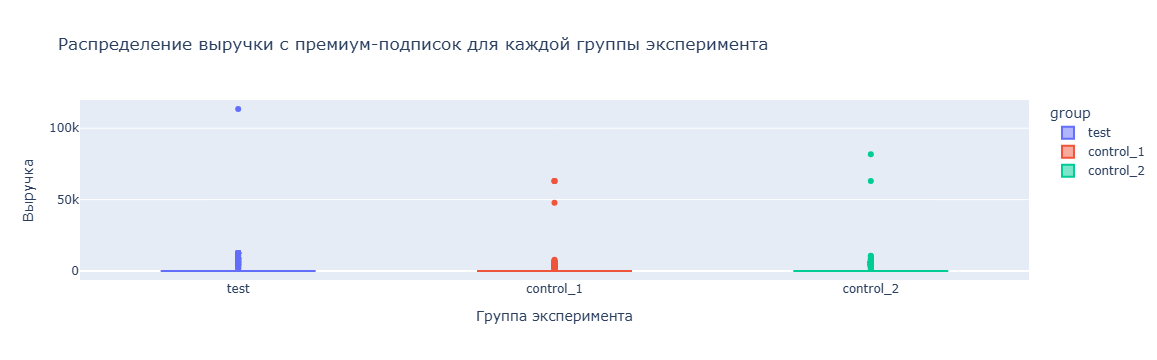

In [193]:
# визуализация распределений выручки по группам
fig = px.box(
    premium_revenue_copy,
    x='group',
    y='premium_revenue',
    color='group',
    title='Распределение выручки с премиум-подписок для каждой группы эксперимента'
)

fig.update_layout(
    yaxis_title='Выручка',
    xaxis_title='Группа эксперимента',
)

fig.show()

В нашем случае выбросы являются частью выручки. Это не ошибки в данных, но выбросы могут оказать сильное влияние на метрики ARPU и ARPPU. Учитывая что выбросы это скорее исключительные случаи, а не закономерность наших данных, стоит рассмотреть по два распределения для каждой метрики: с выбросами и без них. Это создаст более полную картину в отношении метрик. 

По таблице топ 10 выбросов из ячейки выше + из визуализации, мы видим, что отсечка, с которой появляется 7 наших выбросов это **premium_revenue = 47723.0**. Избавимся от выбросов и посмотрим на наши данные по выручке без них:

In [225]:
# убираем выбросы из данных о выручке по продажам премиума
premium_revenue_row = premium_revenue_copy[premium_revenue_copy.premium_revenue < 47000]
# посмотрим как теперь выглядит топ 10 самых больших транзакций по выручке в наших данных
premium_revenue_row.sort_values('premium_revenue', ascending=False).head(10)

,uid,group,premium_revenue
2106,891448377,test,12597.0
178,891882681,test,12597.0
837,892186941,test,12597.0
43,891589239,test,12597.0
145,891806436,test,12597.0
3156,891605694,test,12597.0
588,891346269,test,12597.0
440,891406224,test,12597.0
1182,892347657,test,12597.0
1717,892050108,test,12597.0


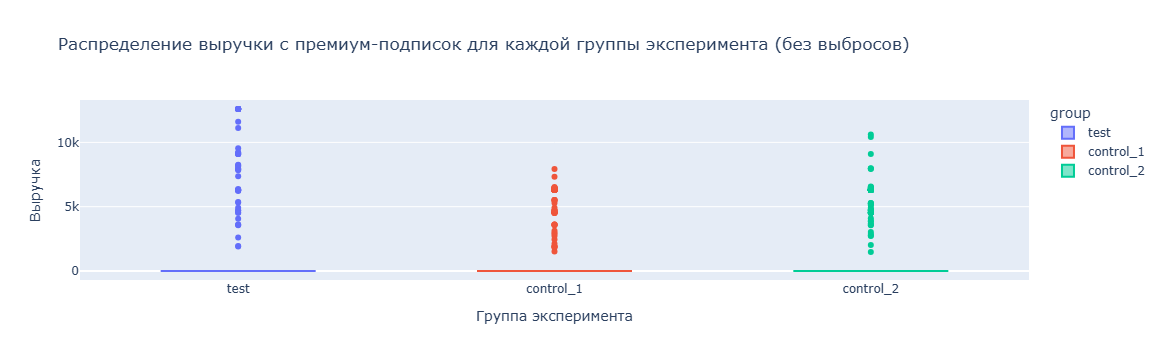

In [226]:
# визуализация распределений выручки по группам (без выбросов)
fig = px.box(
    premium_revenue_row,
    x='group',
    y='premium_revenue',
    color='group',
    title='Распределение выручки с премиум-подписок для каждой группы эксперимента (без выбросов)'
)

fig.update_layout(
    yaxis_title='Выручка',
    xaxis_title='Группа эксперимента',
)

fig.show()

Далее мы будем заниматься рассчётом и сравнением ARPU и ARPPU. Обе эти метрики опираются на среднее значение в наших распределениях. Как мы знаем, среднее значение очень чувствительно к выбросам, поэтому будем проводить рассчёты как по распределениям с выбросами, так и без них. Однако более корректные результаты анализа действительно можно получить только анализируя распределения без выбросов, ведь среднее действительно очень сильно зависит от выбросов в данных. Выбросы могут создавать ложный эффект при анализе средних значений.

___
## Анализ (ARPU) средней выручки от первой покупки премиум-подписки 

Теперь посмотрим, отличается ли ARPU между группами статистически значимо. (Average Revenue Per User) — это средняя выручка, получаемая компанией с одного пользователя. ARPU это среднее значение распределения revenue (выручки) с покупок премиу-подписки новыми пользователями. Будем рассматривать как распределения с выбросами, так и без них. 

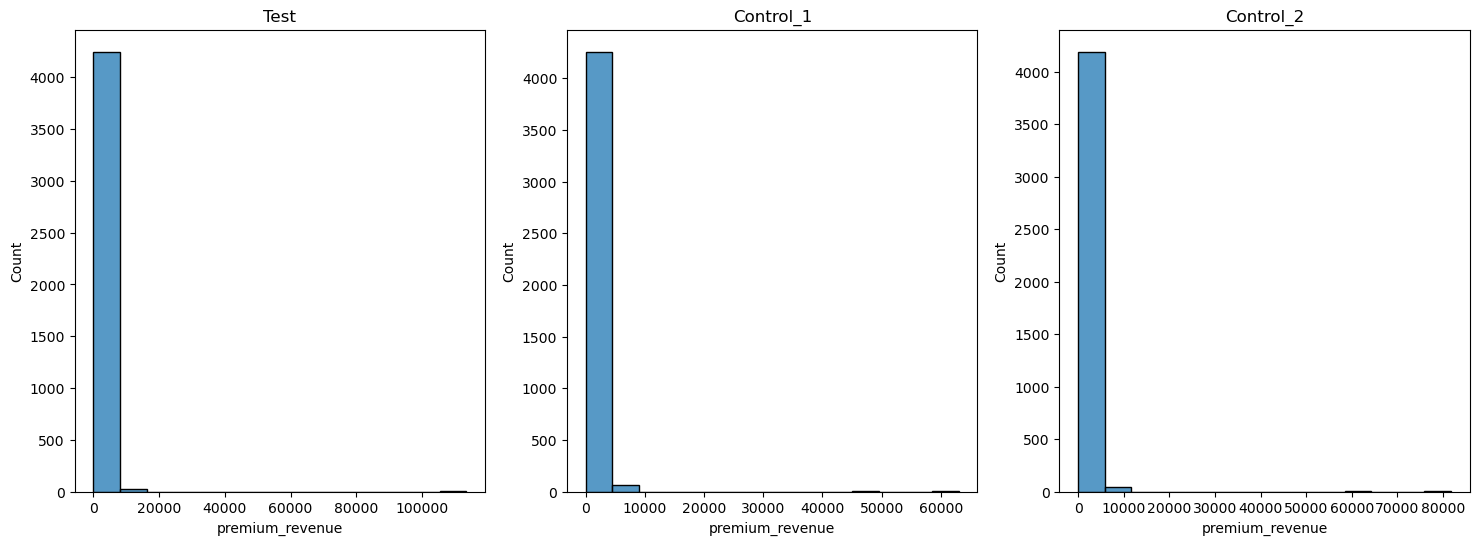

In [227]:
# здесь представлены распределения выручки для каждой группы 
ig, axes = plt.subplots(1, 3, figsize=(18, 6)) # 1 строка, 3 столбца

# график распределения выручки для выборки test
sns.histplot(data=premium_revenue_copy.query("group=='test'"), x='premium_revenue', ax=axes[0])
axes[0].set_title('Test')
# график распределения выручки для выборки control_1
sns.histplot(data=premium_revenue_copy.query("group=='control_1'"), x='premium_revenue', ax=axes[1])
axes[1].set_title('Сontrol_1')
# график распределения выручки для выборки control_2
sns.histplot(data=premium_revenue_copy.query("group=='control_2'"), x='premium_revenue', ax=axes[2])
axes[2].set_title('Сontrol_2')

plt.show()

Распределения выручки в каждог группе выглядят ассиметричными и ненормальными. Для уверенности посмотрим результаты теста Д'Агостино-Пирсона, который проверяет распределение на нормальность. 

In [195]:
# тест Д'Агостино-Пирсона в pingouin
pg.normality(premium_revenue_copy.query("group=='test'").premium_revenue, method='normaltest')

,W,pval,normal
premium_revenue,13143.672818,0.0,False


Распределение выручки в тестовой группе (test) не является нормальным.

In [196]:
# тест Д'Агостино-Пирсона в pingouin
pg.normality(premium_revenue_copy.query("group=='control_1'").premium_revenue, method='normaltest')

,W,pval,normal
premium_revenue,10821.469296,0.0,False


Распределение выручки в первой контрольной группе (control_1) не является нормальным.

In [197]:
# тест Д'Агостино-Пирсона в pingouin
pg.normality(premium_revenue_copy.query("group=='control_2'").premium_revenue, method='normaltest')

,W,pval,normal
premium_revenue,11648.686992,0.0,False


Распределение выручки во второй контрольной группе (control_2) не является нормальным.

Настало времы выбрать статистический тест для сравнения средних значений выручки в наших выборках. Мы выяснили что:
- тест будет проводиться по количественной переменной (выручка - измеримая величина)
- нам нужно сравнить именно средние значения
- распределения выручки являются ассиметричными
- распределения выручки не прошли тест на нормальность
- распределения выручки имеют явные выбросы
- мы будем сравнивать средние показатели выручки в трёх группах

Получается, для сравнения средних значений выручки (ARPU) нам может подойти два статистических теста:
- дисперсионный анализ (ANOVA)
- bootstrap
  
Однако дисперсионный анализ имеет серьёзные ограничения, требует чтобы выполнялся ряд допущений (таких же как для t-теста). Мы сможем провести дисперсионный анализ только в случае когда выборки выполненяют все 4 допущения:
1. Независимость наблюдений.
2. Отсутствие аномальных наблюдений (выбросов).
3. Равенство дисперсий между ГС.
4. Нормальность обеих ГС.

Все эти допущения не могут быть выполнены в нашем случае. Однако это может стать возможным, если мы прологарифмируем распределения. Но тогда мы уже будем работать со средним логарифма выручки. Интерпретация результатов теста в таком случае станет сложнее. 

Тест с помощью bootstrap не требует никаких серьёзных допущений. Этот метод может работать в условиях ненормального распределения, наличия выбросов в данных и ассемитричности распределений. Также с помощью бутстрапа мы сможем сразу сравнивать средние. Единственное, так как мы будем работать с тремя выборками (то есть будем проводить три попарных сравнения), нам следует сделать поправку на множественные сравнения. Применим поправку Бонферрони, когда будем заниматься рассчётом доверительных интервалов. 

Вывод: будем применять метод бутстрапа для сравнения средних значений выручки (ARPU)

Зафиксируем гипотезы для метода бутстрап:

- H0: различий между средними значениями выручки с пользователя (ARPU) нет
- H1: средние значения выручки с пользователя (ARPU) отличаются

In [198]:
def two_sample_boot(x, y, stat, reps=10000, seed=None):

    boot_data = [] #складываем сюда результаты вычислений
    np.random.seed(seed=seed) #фиксируем "зерно" для одинакового рандома

    #повторяем процедуру n раз
    for _ in range(reps):

        sample_x = x.sample(frac=1, replace=True) #генерируем бут-выборку для x
        sample_y = y.sample(frac=1, replace=True) #генерируем бут-выборку для y
        sample_stat_diff = stat(sample_x) - stat(sample_y) #считаем разницу статистик между бут-распределениями
        boot_data.append(sample_stat_diff) # добавляем результат в список

    return(np.array(boot_data))

Пройдёмся по каждому аргументу этой функции:

- series — выборка, которую мы будем бутстрапить. Должна быть пандасовской серией, иначе говоря, колонкой какого-то датафрейма.
- stat — та статистика (=статистический показатель), которая нас интересует: среднее, медиана, квантиль и так далее. Должна быть функцией, указывается без скобок. Например, если мы хотим бутстрапить среднее, то мы можем использовать функцию np.mean(), и тогда код будет выполняться так: boot_func(series, np.mean).
- reps — количество повторений бутстрапа, по умолчанию 20000 .
- seed — стартовое значение ("зерно") генератора псевдослучайных чисел.
Результат этой функции — бут-распределение статистики. Именно с ним мы и будем работать.

Зачем нам нужно seed? Это связано со случайным характером работы бутстрапа — состав каждой бут-выборки определяется случайным образом, и поэтому результаты будут немного отличаться друг от друга при каждом повторном запуске функции. Этот аргумент может помочь зафиксировать результат, чтобы выдавать каждый раз одинаковую генерацию. Но в нашем случае поставим его None. В данном случае нет необходимости фиксировать результат рандома

Применим метод бутстрапа и посмотрим какими получились распределения средних значений выручки по каждой группе в итоге. 

Также в силу того, что мы делаем множественные сравнения, скорректируем порог значимости для проведения эксперимента ориентируясь на поправку Бонферрони. По сути, мы должны просто поделить порог значимости α на число сравнений либо умножить p-value на число сравнений.

Статистический вывод с помощью бутстрапа, как правило, делается с помощью доверительных интервалов. Самый простой способ их посчитать — использовать уже знакомую нам формулу нормального доверительного интервала. Однако у нормального доверительного интервала есть очевидный недостаток: он требует нормальности бут-распределения. Чем меньше оно похоже на нормальное, тем менее точным будет результирующий интервал. 

Наши распределения выручки похожи на логарифмические распределения. При применении метода бутстрапа мы не можем полностью гарантировать, что эти распределения станут нормальными. Часто после применения метода бутстрапа такие распределения становятся более приближены к виду нормального, но ассиметрия (скошенность) остаётся выраженной. В таком случае нормальные доверительные интервалы могут исказить результаты бутстрапа. Поэтому обычно на практике интервал считают совсем иначе: путём расчёта соответствующих квантилей (процентилей) бут-распределения. Так мы далее и сделаем + применим поправку Бонферрони для рассчёта процентилей.

In [199]:
# рассчёт границ квантилей бут-распределения (учитывая поправку Бонферрони)
prob = 0.05
alpha_bonf = (1.0 - prob / 3)
p_const = 1 - alpha_bonf # уровень значимости p-value с поправкой бонферрони 
low_p, hight_p = round((p_const / 2), 4), round((1 - p_const / 2), 4)

print(f"Для {round(alpha_bonf, 4) * 100}%-ого доверительного интервала: нижняя граница квантиля бут-распределения - {low_p}, верхняя граница - {hight_p}")

Для 98.33%-ого доверительного интервала: нижняя граница квантиля бут-распределения - 0.0083, верхняя граница - 0.9917


Данные рассчёты с границами квантилей подходят как для анализа распределения с выбросами, так и без них

### Сравним ARPU между группами (распределение выручки С ВЫБРОСАМИ)

In [236]:
# задаём выборки с распределением выручки по группам
sample_test      = premium_revenue_copy.query("group=='test'").premium_revenue
sample_control_1 = premium_revenue_copy.query("group=='control_1'").premium_revenue
sample_control_2 = premium_revenue_copy.query("group=='control_2'").premium_revenue

In [237]:
# применяем метод бутстрапа для сравнения средних значений выручки (test/control_1)
ci_tc1_low = float(pd.Series(two_sample_boot(sample_test, sample_control_1, np.mean)).quantile(low_p).round(4))
ci_tc1_hight = float(pd.Series(two_sample_boot(sample_test, sample_control_1, np.mean)).quantile(hight_p).round(4))

print(f"{round(alpha_bonf, 4) * 100}%-ый доверительный интервал для ARPU тестовой и первой контрольной группы: [{ci_tc1_low}, {ci_tc1_hight}]")

98.33%-ый доверительный интервал для ARPU тестовой и первой контрольной группы: [-127.2154, 77.5029]


В результате применения метода бутстрапа мы получили доверительный интервал, который включает в себя значение 0. Этот результат интерпретируется как отсутствие статистически значимых различий между средними значениями выручки (ARPU) у тестовой и первой контрольной группы.

**Итог: Принимаем H0. Разница в ARPU у тестовой (test) и первой контрольной (control_1) группы отсутствует.**

In [238]:
# применяем метод бутстрапа для сравнения средних значений выручки (control_1/control_2)
ci_c1c2_low = float(pd.Series(two_sample_boot(sample_control_1, sample_control_2, np.mean)).quantile(low_p).round(4))
ci_c1c2_hight = float(pd.Series(two_sample_boot(sample_control_1, sample_control_2, np.mean)).quantile(hight_p).round(4))

print(f"{round(alpha_bonf, 4) * 100}%-ый доверительный интервал для ARPU первой и второй контрольных групп: [{ci_c1c2_low}, {ci_c1c2_hight}]")

98.33%-ый доверительный интервал для ARPU первой и второй контрольных групп: [-92.8262, 103.2581]


Здесь аналогично. Так как полученный доверительный интервал включает значение 0, его интерпретируем как отсутствие статистически значимых различий по ARPU между первой и второй контрольными группами.

**Итог: Принимаем H0. Разница в ARPU у первой (control_1) и второй (control_2) контрольными группами отсутствует.**

In [239]:
# применяем метод бутстрапа для сравнения средних значений выручки (test/control_2)
ci_tc2_low = float(pd.Series(two_sample_boot(sample_test, sample_control_2, np.mean)).quantile(low_p).round(4))
ci_tc2_hight = float(pd.Series(two_sample_boot(sample_test, sample_control_2, np.mean)).quantile(hight_p).round(4))

print(f"{round(alpha_bonf, 4) * 100}%-ый доверительный интервал для ARPU тестовой и второй контрольной группы: [{ci_tc2_low}, {ci_tc2_hight}]")

98.33%-ый доверительный интервал для ARPU тестовой и второй контрольной группы: [-119.7349, 80.5511]


Аналогично. Полученный доверительный интервал включает значение 0 -> интерпретируем как отсутствие статистически значимых различий по ARPU между тестовой и второй контрольной группаой.

**Итог: Принимаем H0. Разница в ARPU у тестовой (test) и второй контрольной (control_2) группой отсутствует.**

### Сравним ARPU между группами (распределение выручки БЕЗ ВЫБРОСОВ)

Посмотрим как выглядят распределения выручки без выбросов.

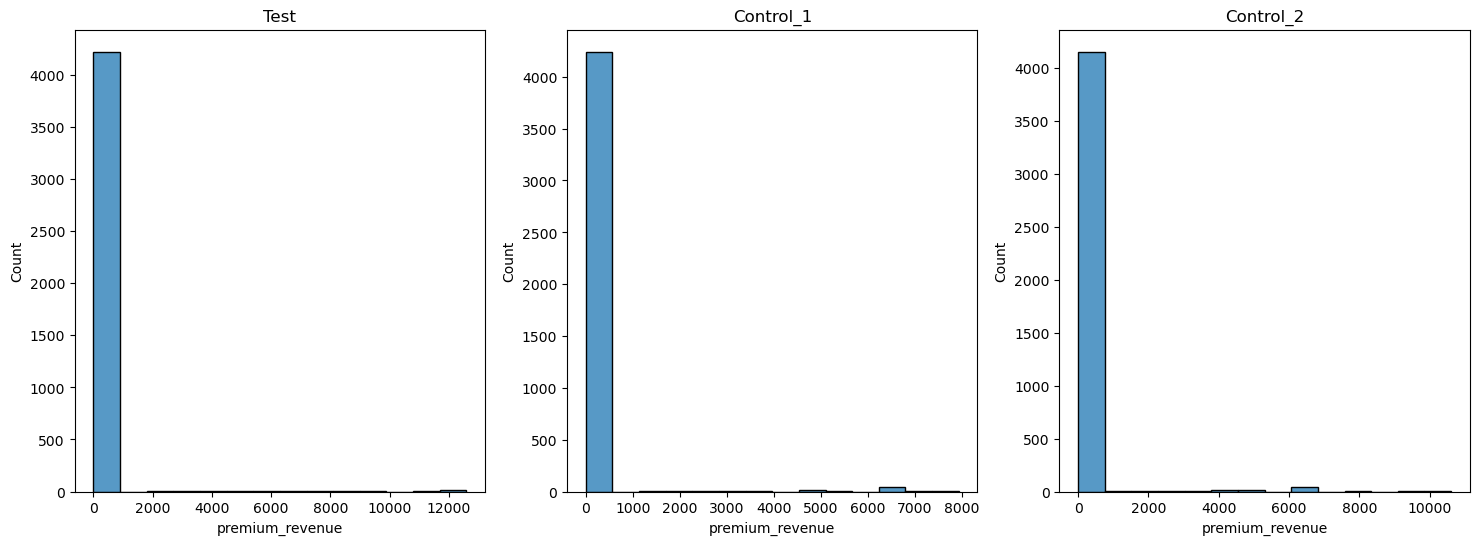

In [230]:
# здесь представлены распределения выручки для каждой группы (без выбросов)
ig, axes = plt.subplots(1, 3, figsize=(18, 6)) # 1 строка, 3 столбца

# график распределения выручки для выборки test
sns.histplot(data=premium_revenue_row.query("group=='test'"), x='premium_revenue', ax=axes[0])
axes[0].set_title('Test')
# график распределения выручки для выборки control_1
sns.histplot(data=premium_revenue_row.query("group=='control_1'"), x='premium_revenue', ax=axes[1])
axes[1].set_title('Сontrol_1')
# график распределения выручки для выборки control_2
sns.histplot(data=premium_revenue_row.query("group=='control_2'"), x='premium_revenue', ax=axes[2])
axes[2].set_title('Сontrol_2')

plt.show()

Картина распределений без выбросов аналогичная. Также применим бутстрап для сравнения ARPU между группами.

In [240]:
# задаём выборки с распределением выручки (без выбросов) по группам
sample_test_row      = premium_revenue_row.query("group=='test'").premium_revenue
sample_control_1_row = premium_revenue_row.query("group=='control_1'").premium_revenue
sample_control_2_row = premium_revenue_row.query("group=='control_2'").premium_revenue

In [241]:
# применяем метод бутстрапа для сравнения средних значений выручки (test/control_1)
ci_tc1_low = float(pd.Series(two_sample_boot(sample_test_row, sample_control_1_row, np.mean)).quantile(low_p).round(4))
ci_tc1_hight = float(pd.Series(two_sample_boot(sample_test_row, sample_control_1_row, np.mean)).quantile(hight_p).round(4))

print(f"{round(alpha_bonf, 4) * 100}%-ый доверительный интервал для ARPU тестовой и первой контрольной группы: [{ci_tc1_low}, {ci_tc1_hight}]")

98.33%-ый доверительный интервал для ARPU тестовой и первой контрольной группы: [-40.0745, 45.7721]


Мы также получили доверительный интервал, который включает в себя значение 0. Этот результат интерпретируется как отсутствие статистически значимых различий между средними значениями выручки (ARPU) у тестовой и первой контрольной группы. Даже неспотря на то что мы взяли распределение без выбросов.

**Итог: Принимаем H0. Разница в ARPU у тестовой (test) и первой контрольной (control_1) группы отсутствует.**

In [242]:
# применяем метод бутстрапа для сравнения средних значений выручки (control_1/control_2)
ci_c1c2_low = float(pd.Series(two_sample_boot(sample_control_1_row, sample_control_2_row, np.mean)).quantile(low_p).round(4))
ci_c1c2_hight = float(pd.Series(two_sample_boot(sample_control_1_row, sample_control_2_row, np.mean)).quantile(hight_p).round(4))

print(f"{round(alpha_bonf, 4) * 100}%-ый доверительный интервал для ARPU первой и второй контрольных групп: [{ci_c1c2_low}, {ci_c1c2_hight}]")

98.33%-ый доверительный интервал для ARPU первой и второй контрольных групп: [-56.4618, 22.1697]


Здесь аналогично. Так как полученный доверительный интервал включает значение 0, его интерпретируем как отсутствие статистически значимых различий по ARPU между первой и второй контрольными группами.

**Итог: Принимаем H0. Разница в ARPU у первой (control_1) и второй (control_2) контрольными группами отсутствует.**

In [243]:
# применяем метод бутстрапа для сравнения средних значений выручки (test/control_2)
ci_tc2_low = float(pd.Series(two_sample_boot(sample_test_row, sample_control_2_row, np.mean)).quantile(low_p).round(4))
ci_tc2_hight = float(pd.Series(two_sample_boot(sample_test_row, sample_control_2_row, np.mean)).quantile(hight_p).round(4))

print(f"{round(alpha_bonf, 4) * 100}%-ый доверительный интервал для ARPU тестовой и второй контрольной группы: [{ci_tc2_low}, {ci_tc2_hight}]")

98.33%-ый доверительный интервал для ARPU тестовой и второй контрольной группы: [-60.0639, 29.2035]


Аналогично. Полученный доверительный интервал включает значение 0 -> интерпретируем как отсутствие статистически значимых различий по ARPU между тестовой и второй контрольной группаой.

**Итог: Принимаем H0. Разница в ARPU у тестовой (test) и второй контрольной (control_2) группой отсутствует.**

### Вывод ARPU

В результате сравнения ARPU между группами с помощью метода бутстрапа, мы не нашли накаких статистически значимых различий между группами. После изменения цены на премиум подписку мы не стали зарабатывать больше, а также, к счастью, не начали терять в прибыли. Причём мы сравнили как распределения с выбросами, так и без выбросов, и всё равно не обнаружили нкаких статистически значимых различий. Это значит, что наши изменения цены никак не отразились на ARPU, а значит, не отразились и на нашей глобальной прибыли.

🟨ARPU никак не изменилась в тестовой группе относительно обеих контрольных групп (проверяли выручку с выбросами/без выбросов)🟨

___
## Анализ (ARPPU) средней выручки от первой покупки премиум-подписки по платящим пользователям

Для того чтобы сделать исчерпывающий вывод о результатах эксперимента, осталось только посмотреть на пользователей, которые являются нашей платящей аудиторией. Далее займёмся рассмотрением ARPPU и сравнением этого показателя между выборками. 

In [245]:
# отбираем только тех пользователей, которые вносили оплату за премиум (распределение выручки с выбросами)
premium_revenue_arppu = premium_revenue_copy.query('premium_revenue > 0')
premium_revenue_arppu

,uid,group,premium_revenue
43,891589239,test,12597.0
145,891806436,test,12597.0
178,891882681,test,12597.0
215,892211106,test,4537.0
401,892236423,test,6292.0
...,...,...,...
12699,891883854,control_2,6461.0
12719,891826944,control_2,6292.0
12730,892385232,control_2,6292.0
12801,891213609,control_2,6292.0


Посмотрим как выглядит это распределение на визуализации

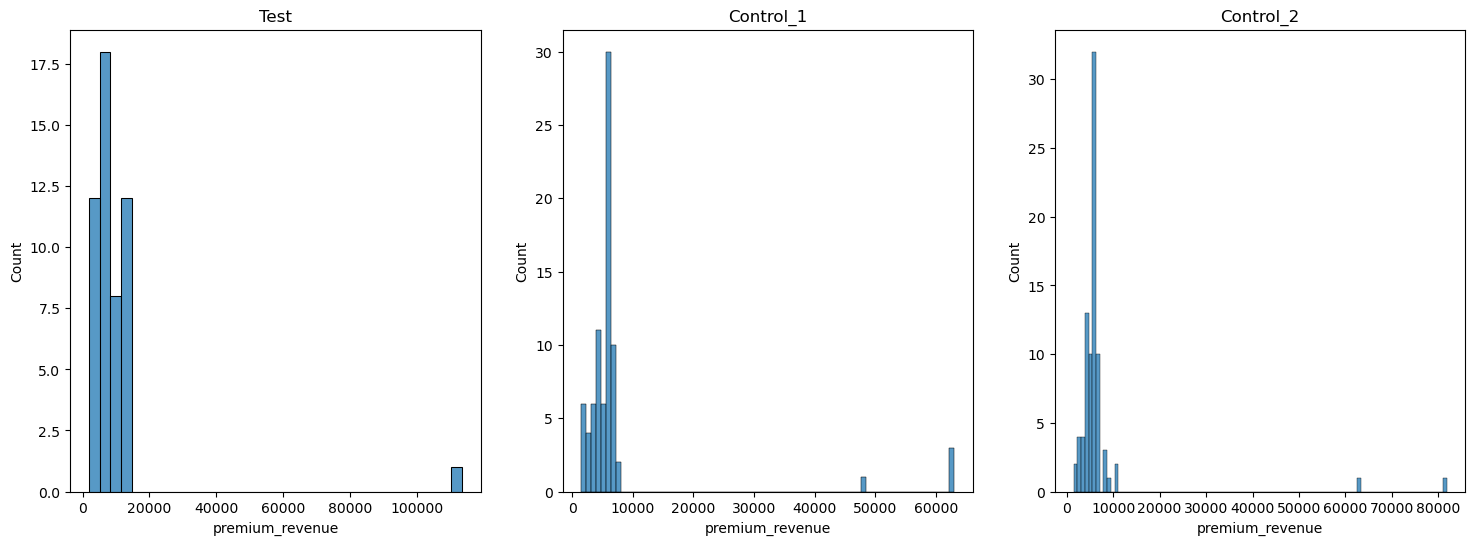

In [249]:
# здесь представлены распределения выручки только платящих пользователей для каждой группы (с выброами)
ig, axes = plt.subplots(1, 3, figsize=(18, 6)) # 1 строка, 3 столбца

# график распределения выручки по платящим юзерам для выборки test
sns.histplot(data=premium_revenue_arppu.query("group=='test'"), x='premium_revenue', ax=axes[0])
axes[0].set_title('Test')
# график распределения выручки по платящим юзерам для выборки control_1
sns.histplot(data=premium_revenue_arppu.query("group=='control_1'"), x='premium_revenue', ax=axes[1])
axes[1].set_title('Сontrol_1')
# график распределения выручки по платящим юзерам для выборки control_2
sns.histplot(data=premium_revenue_arppu.query("group=='control_2'"), x='premium_revenue', ax=axes[2])
axes[2].set_title('Сontrol_2')

plt.show()

In [246]:
# отбираем только тех пользователей, которые вносили оплату за премиум (распределение выручки без выбросов) 
premium_revenue_arppu_row = premium_revenue_row.query('premium_revenue > 0')
premium_revenue_arppu_row

,uid,group,premium_revenue
43,891589239,test,12597.0
145,891806436,test,12597.0
178,891882681,test,12597.0
215,892211106,test,4537.0
401,892236423,test,6292.0
...,...,...,...
12699,891883854,control_2,6461.0
12719,891826944,control_2,6292.0
12730,892385232,control_2,6292.0
12801,891213609,control_2,6292.0


Посмотрим как выглядит это распределение на визуализации

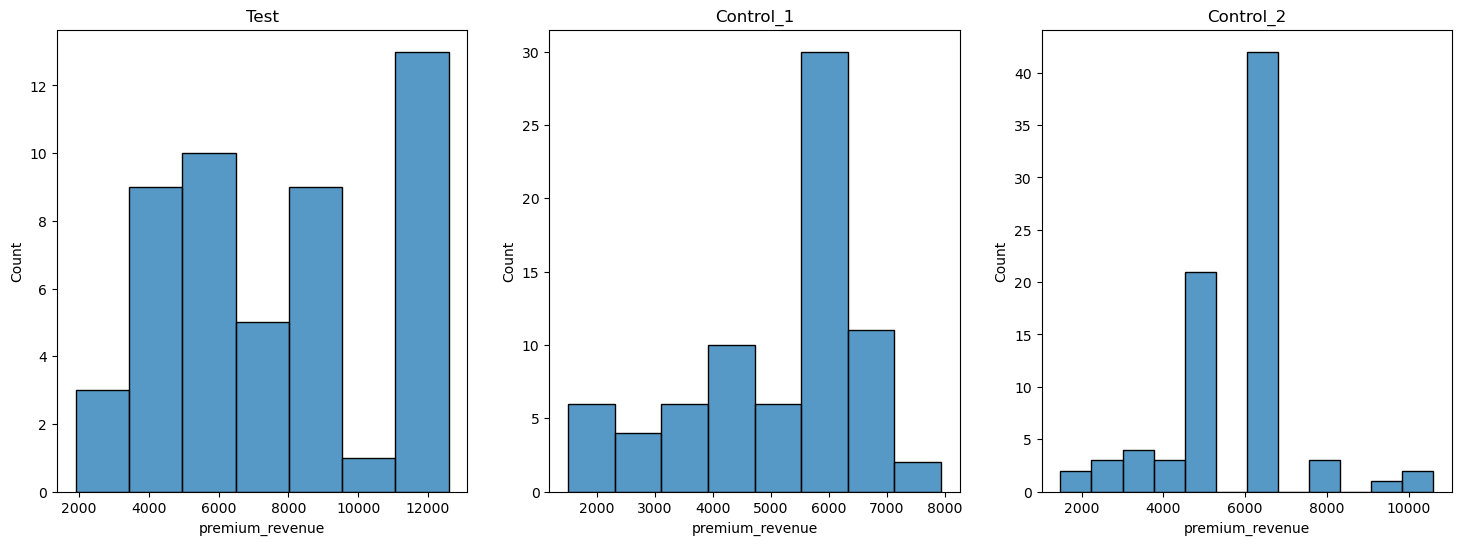

In [252]:
# здесь представлены распределения выручки только платящих пользователей для каждой группы (без выбросов)
ig, axes = plt.subplots(1, 3, figsize=(18, 6)) # 1 строка, 3 столбца

# график распределения выручки по платящим юзерам для выборки test
sns.histplot(data=premium_revenue_arppu_row.query("group=='test'"), x='premium_revenue', ax=axes[0])
axes[0].set_title('Test')
# график распределения выручки по платящим юзерам для выборки control_1
sns.histplot(data=premium_revenue_arppu_row.query("group=='control_1'"), x='premium_revenue', ax=axes[1])
axes[1].set_title('Сontrol_1')
# график распределения выручки по платящим юзерам для выборки control_2
sns.histplot(data=premium_revenue_arppu_row.query("group=='control_2'"), x='premium_revenue', ax=axes[2])
axes[2].set_title('Сontrol_2')

plt.show()

В обеих случаях видим (как с выбросами, так и без них), что распределения отличаются от нормальных. Основываясь на тех же довадах, по которым мы приняли использовать метод бутстрапа для анализа ARPU, будем также использовать метод бутстрапа и для анализа ARPPU. 

Тест с помощью bootstrap не требует никаких серьёзных допущений. Этот метод может работать в условиях ненормального распределения, наличия выбросов в данных и ассемитричности распределений. Также с помощью бутстрапа мы сможем сразу сравнивать средние. Единственное, так как мы будем работать с тремя выборками (то есть будем проводить три попарных сравнения), нам следует сделать поправку на множественные сравнения. Применим поправку Бонферрони, когда будем заниматься рассчётом доверительных интервалов.

Вывод: будем применять метод бутстрапа для сравнения средних значений выручки по платящим пользователям (ARPPU). Саму функцию метода бутстрапа возьмём такую же, как мы брали при анализе ARPU. Рассчёт границ бут распределения также возьмём из рассчётов, которые использовались для анализа ARPU.

In [207]:
# рассчёт границ квантилей бут-распределения (учитывая поправку Бонферрони)
prob = 0.05
alpha_bonf = (1.0 - prob / 3)
p_const = 1 - alpha_bonf # уровень значимости p-value с поправкой бонферрони 
low_p, hight_p = round((p_const / 2), 4), round((1 - p_const / 2), 4)

print(f"Для {round(alpha_bonf, 4) * 100}%-ого доверительного интервала: нижняя граница квантиля бут-распределения - {low_p}, верхняя граница - {hight_p}")

Для 98.33%-ого доверительного интервала: нижняя граница квантиля бут-распределения - 0.0083, верхняя граница - 0.9917


Зафиксируем гипотезы для метода бутстрап:

- H0: различий между средними значениями выручки с платящего пользователя (ARPPU) нет
- H1: средние значения выручки с платящего пользователя (ARPPU) отличаются

### Сравним ARPPU между группами (распределение выручки С ВЫБРОСАМИ)

In [209]:
# задаём выборки с распределением выручки по группам
sample_test_arppu      = premium_revenue_arppu.query("group=='test'").premium_revenue
sample_control_1_arppu = premium_revenue_arppu.query("group=='control_1'").premium_revenue
sample_control_2_arppu  = premium_revenue_arppu.query("group=='control_2'").premium_revenue

In [210]:
# применяем метод бутстрапа для сравнения средних значений выручки (test/control_1)
ci_tc1_low = float(pd.Series(two_sample_boot(sample_test_arppu, sample_control_1_arppu, np.mean)).quantile(low_p).round(4))
ci_tc1_hight = float(pd.Series(two_sample_boot(sample_test_arppu, sample_control_1_arppu, np.mean)).quantile(hight_p).round(4))

print(f"{round(alpha_bonf, 4) * 100}%-ый доверительный интервал для ARPU тестовой и первой контрольной группы: [{ci_tc1_low}, {ci_tc1_hight}]")

98.33%-ый доверительный интервал для ARPU тестовой и первой контрольной группы: [-3314.9381, 9107.8019]


Полученный доверительный интервал включает значение 0 -> интерпретируем как отсутствие статистически значимых различий по ARPU между тестовой и первой контрольной группой.

**Итог: Принимаем H0. Разница в ARPU у тестовой (test) и первой контрольной (control_1) группой отсутствует.**

In [211]:
# применяем метод бутстрапа для сравнения средних значений выручки (control_1/control_2)
ci_c1c2_low = float(pd.Series(two_sample_boot(sample_control_1_arppu, sample_control_2_arppu, np.mean)).quantile(low_p).round(4))
ci_c1c2_hight = float(pd.Series(two_sample_boot(sample_control_1_arppu, sample_control_2_arppu, np.mean)).quantile(hight_p).round(4))

print(f"{round(alpha_bonf, 4) * 100}%-ый доверительный интервал для ARPU первой и второй контрольных групп: [{ci_c1c2_low}, {ci_c1c2_hight}]")

98.33%-ый доверительный интервал для ARPU первой и второй контрольных групп: [-3561.8938, 5108.4134]


Полученный доверительный интервал включает значение 0 -> интерпретируем как отсутствие статистически значимых различий по ARPU между первой и второй контрольной группой.

**Итог: Принимаем H0. Разница в ARPU между первой (control_1) и второй (control_2) контрольными группами отсутствует.**

In [212]:
# применяем метод бутстрапа для сравнения средних значений выручки (test/control_2)
ci_tc2_low = float(pd.Series(two_sample_boot(sample_test_arppu, sample_control_2_arppu, np.mean)).quantile(low_p).round(4))
ci_tc2_hight = float(pd.Series(two_sample_boot(sample_test_arppu, sample_control_2_arppu, np.mean)).quantile(hight_p).round(4))

print(f"{round(alpha_bonf, 4) * 100}%-ый доверительный интервал для ARPU тестовой и второй контрольной группы: [{ci_tc2_low}, {ci_tc2_hight}]")

98.33%-ый доверительный интервал для ARPU тестовой и второй контрольной группы: [-2206.9821, 9708.4248]


Полученный доверительный интервал включает значение 0 -> интерпретируем как отсутствие статистически значимых различий по ARPU между тестовой и второй контрольной группой.

**Итог: Принимаем H0. Разница в ARPU у тестовой (test) и второй контрольной (control_2) группой отсутствует.**

### Сравним ARPPU между группами (распределение выручки БЕЗ ВЫБРОСОВ)

In [221]:
# задаём выборки с распределением выручки по группам
sample_test_arppu_row       = premium_revenue_arppu_row.query("group=='test'").premium_revenue
sample_control_1_arppu_row  = premium_revenue_arppu_row.query("group=='control_1'").premium_revenue
sample_control_2_arppu_row  = premium_revenue_arppu_row.query("group=='control_2'").premium_revenue

In [222]:
# применяем метод бутстрапа для сравнения средних значений выручки (test/control_1)
ci_tc1_low = float(pd.Series(two_sample_boot(sample_test_arppu_row, sample_control_1_arppu_row, np.mean)).quantile(low_p).round(4))
ci_tc1_hight = float(pd.Series(two_sample_boot(sample_test_arppu_row, sample_control_1_arppu_row, np.mean)).quantile(hight_p).round(4))

print(f"{round(alpha_bonf, 4) * 100}%-ый доверительный интервал для ARPU тестовой и первой контрольной группы: [{ci_tc1_low}, {ci_tc1_hight}]")

98.33%-ый доверительный интервал для ARPU тестовой и первой контрольной группы: [1410.3975, 3831.7246]


Здесь мы получили доверительный интервал, который не включает 0 и содежит только положительные значения. Это значит, что существует статистически значимая разница между ARPPU тестовой группы и первой контрольной. Более того, ARPPU тестовой группы значимо вырос относительно первой контрольной. То есть мы фиксируем рост ARPPU после изменения стоимости премиума. 

**Итог: Отвергаем H0. Разница в ARPPU у тестовой (test) и первой контрольной (control_1) группой существует. ARPPU выросла в тестовой группе относительно первой контрольной.**

In [223]:
# применяем метод бутстрапа для сравнения средних значений выручки (control_1/control_2)
ci_c1c2_low = float(pd.Series(two_sample_boot(sample_control_1_arppu_row, sample_control_2_arppu_row, np.mean)).quantile(low_p).round(4))
ci_c1c2_hight = float(pd.Series(two_sample_boot(sample_control_1_arppu_row, sample_control_2_arppu_row, np.mean)).quantile(hight_p).round(4))

print(f"{round(alpha_bonf, 4) * 100}%-ый доверительный интервал для ARPU первой и второй контрольных групп: [{ci_c1c2_low}, {ci_c1c2_hight}]")

98.33%-ый доверительный интервал для ARPU первой и второй контрольных групп: [-960.6172, 197.5969]


Полученный доверительный интервал включает значение 0 -> интерпретируем как отсутствие статистически значимых различий по ARPPU между первой и второй контрольной группой.

**Итог: Принимаем H0. Разница в ARPPU между первой (control_1) и второй (control_2) контрольными группами отсутствует.**

In [224]:
# применяем метод бутстрапа для сравнения средних значений выручки (test/control_2)
ci_tc2_low = float(pd.Series(two_sample_boot(sample_test_arppu_row, sample_control_2_arppu_row, np.mean)).quantile(low_p).round(4))
ci_tc2_hight = float(pd.Series(two_sample_boot(sample_test_arppu_row, sample_control_2_arppu_row, np.mean)).quantile(hight_p).round(4))

print(f"{round(alpha_bonf, 4) * 100}%-ый доверительный интервал для ARPU тестовой и второй контрольной группы: [{ci_tc2_low}, {ci_tc2_hight}]")

98.33%-ый доверительный интервал для ARPU тестовой и второй контрольной группы: [1066.5194, 3454.6714]


Снова получили доверительный интервал, который не включает 0 и содежит только положительные значения. Это значит, что существует статистически значимая разница между ARPPU тестовой группы и второй контрольной. Более того, ARPPU тестовой группы значимо вырос относительно второй контрольной. То есть мы фиксируем рост ARPPU после изменения стоимости премиума. 

**Итог: Отвергаем H0. Разница в ARPPU у тестовой (test) и второй контрольной (control_2) группой существует. ARPPU выросла в тестовой группе относительно второй контрольной.**

### Вывод ARPPU

В результате метод bootstrap, выявлены статистически значимые различия между:

1) test + control_1
2) test + control_2
   
Средний чек платещего клиента (ARPPU) в обеих контрольных группах оказался ниже, чем в тестовой. Это значит, что изменение стоимости подписки привело к увеличению среднего чека платящего пользователя. Платящие пользователи стали больше платить за подписку, что является закономерным результатом при увеличении цены подписки.

🟩⬆️ARPPU выросла в тествой группе относительно обеих контрольных🟩

___
## Результаты анализа A/B теста

Мы исследовали три группы пользователей, чтобы отследить какой эффект оказало изменение стоимости премиум-подписки. Что нам удалось выяснить:
- С помощью теста хи-квадрат мы сравнили как вело себя распределение конверсий покупкок премиум-подписки и пробного премиума. Мы хотели выяснить, повлияло ли изменение цены на предпочтение покупать тот или другой вид премиума. По результатам теста оказалось что никакого различия в процентном соотношении покупок основной и пробной подписки нет. Различие в ценах никак не отразилось на желании пользователей предпочитать к покупке премиум-подписку вместо пробной.
  
- С помощью z-теста для конверсий мы сравнили уже конкретно конверсию (CR) в покупку премиум-подписки. Мы хотели понять именно в разрезе премиум-подписок стало ли у нас статистически значимо больше продаж. Оказалось, что конверсия (CR) действительно изменилась в тестовой группе относительно обеих контрольных. Более того, мы выяснили что конверсия (CR) в тестовой группе (где меняли цену) ухудшилась относительно обеих контрольных (где была старая цена). Значит, изменение цены оказало отрицательный эффект на конверсию (CR) в покупку премиум-подписки. Пользователи стали реже покупать премиум после изменения стоимости.
  
- Далее с помощью применения метода bootstrap мы сравнили распределения выручки с пользователя по покупке премиум-подписок. Мы хотели узнать повлияло ли наше изменение на метрику ARPU (среднее значение выручки с клиента). Причём мы сравнивали ARPU распределений выручки как с выбросами, так и без них. Среднее значение очень чувствительно к выбросам и мы убирали их, чтобы посмотреть оказывают ли выбросы эффект на результаты анализа ARPU. Сравнение средних значений при помощи бутстрапа показало, что статистически значимые различия между выборками по метрике ARPU отсутствуют (причём как с выбросами, так и без них не было значимого результата). Для бизнеса это значит, что в денежном эквиваленте, наши изменения не оказали никакого влияния на продукт. Мы не стали зарабатывать больше, но и не потеряли выручку.
  
- И в заключение нашего анализа, также используя метод bootstrap, мы сравнили распределения выручки с платящих пользователей. Мы хотели узнать повлияло ли наше изменение на метрику ARPPU (среднее значение выручки с платящего клиента). Причём мы сравнивали ARPPU распределений выручки как с выбросами, так и без них. Среднее значение очень чувствительно к выбросам и мы убирали их, чтобы посмотреть оказывают ли выбросы эффект на результаты анализа ARPPU. Сравнение средних значений при помощи бутстрапа показало, что статистически значимые различия между выборками по метрике ARPPU действительно существуют (но только в условиях отсутствия выбросов, что является нормой для среднего значения). Причём мы выяснили, что ARPPU в тестовой группе (после изменения стоимости) выросла относительно обеих контрольных групп. Для бизнеса это хорошая новость, однако, если брать все выше перечисленные инсайты в совокупности, мы получаем картину, где изменение цены ухудшило желание клиентов совершать покупки премиума, а у тех, кто произвёл оплату, увеличило средний чек + наша глобальная выручка никак не изменилась. Это всё означает, что наше изменение цены привело к стагнации выручки, потому что ухудшение конверсии (снижение привлекательности) компенсируется выручкой с платящих пользователей (потому что цеа за сам товар увеличилась). Такие результаты сложно назвать эффективными и удовлетворительными для бизнеса.

Вспомним критерии успеха эксперимента, которые мы обозначили в начале анализа. **Ожидаемый эффект**, который хотели увидеть, чтобы утверждать об успешности эксперимента:
- ⬆️Рост CR (конверсия в покупку премиум-подписок)
- ⬆️Рост ARPU (средняя выручка от премиум-подписок)
- ⬆️Рост ARPPU (средняя выручка с платящего пользователя от премиум-подписок)
  
**Реальный эффект**, который оказали изменения по результатам анализа:
- 🟥⬇️Ухудшение CR
- 🟨ARPU никак не изменилась
- 🟩⬆️Рост ARPPU

**Заключение:**

Эксперимент нельзя считать успешным. Мы выяснили, что наши изменения в стоимости ухудшили привлекательность премиум-подписки для пользователей, к тому же мы не начали глобально зарабатывать с этого больше. Единственное положительное изменение было у метрики ARPPU, что обусловлено, скорее всего, исключительно ростом самой цены в бОльшую сторону. Сложилась ситуация, где рост ARPPU компенсируется падением конверсии и не приводит к увеличению прибыли (ARPU). Такие результаты эксперимента нельзя назвать полностью успешными. Результаты скорее спорные. По результатам эксперимента, я бы посоветовала повременить с раскаткой изменений на всех пользователей и провести дополнительные исследования по изменению цены, чтобы получить более устойчивый результат (выдвинуть и протестировать другие гипотезы). Ухудшение конверсии является тревожным знаком, учитывая отсутствие роста ARPU. Пока что мы видим, что метрики CR и ARPPU компенсируют друг друга, но в любой момент баланс метрик может измениться и наша выручка начнёт падать. 